# Seizure Detection — Minimal Pipeline

A self-contained, step-by-step pipeline for binary seizure detection on the
**SWEZ iEEG short** dataset (`data/remote/swiss_eeg_short/`).

The dataset consists of intracranial EEG (iEEG) recordings from epilepsy patients: each `.mat`
file holds a single seizure event sampled at 256 Hz across a variable number of channels (20-64
depending on the electrode montage). No sample-level onset/offset annotations exist, so seizure
labels are derived from a fixed-margin rule: the first and last 3 minutes of each recording are
treated as non-seizure background, and everything in between is assumed to be ictal activity.

This notebook is the **minimal companion** to `seizure_detection_ml_pipeline.ipynb`. It keeps the
same feature set, labelling rule, RFE selection, LOSO validation, and HMM post-processing, but
collapses the experiment matrix down to a single configuration so the whole pipeline can be read
top-to-bottom in one pass:

| | Full pipeline | This notebook |
|---|---|---|
| Classifiers compared | LogisticRegression, RandomForest, XGBoost | LogisticRegression only |
| Label scheme | Binary **and** 4-class | Binary only |
| Class imbalance handling | `class_weight="balanced"` | `class_weight="balanced"` |
| Post-processing compared | Raw / HMM / Forward-backward, x2 label schemes | Raw / Viterbi / Forward-backward |
| Purpose | Compare models and label granularity | Understand *one* well-tuned pipeline end to end |

**Why LogisticRegression?** In the full pipeline notebook, LogisticRegression and XGBoost landed
at nearly identical AUROC under LOSO (~0.63-0.64) — an earlier version of this notebook used
XGBoost, but with no measurable benefit over the simpler, faster, directly-interpretable linear
model, LogisticRegression is used throughout instead. See Section 6 for the full rationale.

**Pipeline at a glance:**

```
Raw .mat files
    └─ sliding windows (2 s / 0.5 s step)
        └─ 15 scalar features per window
            └─ per-file z-score normalisation
                └─ RFE feature selection  (same LogisticRegression, 1-SE rule)
                    └─ LogisticRegression  (binary, class_weight="balanced")
                        └─ HMM smoothing  (Viterbi + forward-backward)
                            └─ metrics & visualisation
```

## Labelling assumption

- first `NON_SEIZURE_MARGIN_SECONDS` (3 min) → non-seizure
- last `NON_SEIZURE_MARGIN_SECONDS` (3 min) → non-seizure
- everything in between → seizure

(No pre-/post-seizure transition zone here — that only exists in the 4-class version in the full
pipeline notebook.)

## Imports

The pipeline uses four groups of libraries:

- **Signal processing / data:** `numpy`, `scipy.io` (`.mat` file loading), `xarray` (labelled
  arrays that CobraBox features expect), `pandas` (tabular results).
- **CobraBox:** `cobrabox` (`cb`) provides the domain-specific EEG features via its `feature.*`
  API — each feature accepts a `SignalData` object and returns a labelled result array.
- **Machine learning:** `scikit-learn` provides everything needed — `StandardScaler` (per-fold
  normalisation), `RFE` (feature selection), `LeaveOneGroupOut` (LOSO split), `clone`, detection
  metrics, and `LogisticRegression`, which is used both to rank features inside RFE and as the
  final classifier trained inside the LOSO loop.
- **Post-processing / plotting / parallelism:** `scipy.special.logsumexp` (numerically stable HMM
  forward-backward), `matplotlib` + `LineCollection`/`Patch` (time-series visualisation),
  `joblib.Parallel`/`delayed` (parallel feature extraction across files).

In [32]:
from itertools import pairwise
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import xarray as xr
from joblib import Parallel, delayed
from matplotlib.collections import LineCollection
from matplotlib.patches import Patch
from scipy.special import logsumexp
from sklearn.base import clone
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import fbeta_score, recall_score, roc_auc_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler

import cobrabox as cb

## 1. Configuration

All tunable parameters live here. Change them once and re-run the affected sections — no need to
hunt through the code.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `FS` | 256 Hz | Sampling rate of the SWEZ dataset |
| `WINDOW_SECONDS` | 2 s | Each window captures ~3 cycles of the slowest seizure rhythm (delta, 1 Hz) and enough high-frequency content for coherence estimation |
| `STEP_SECONDS` | 0.5 s | 75 % overlap — dense enough to localise onset/offset precisely |
| `NON_SEIZURE_MARGIN_SECONDS` | 180 s | SWEZ short recordings always start and end in the interictal period; the first/last 3 min are labelled non-seizure |
| `K_STEPS` | [3, 5, 8, 10] | Feature subset sizes swept by RFE; best k chosen by 1-SE rule on AUROC |
| `REEXTRACT` | False | Set True to delete cached CSVs and re-run extraction from scratch |

**Key choices and their rationale:**

- **Window 2 s / step 0.5 s** — matches the full pipeline notebook exactly, so features extracted
  here are numerically comparable to that notebook's (cached separately, under a different
  `OUT_DIR`, so the two never overwrite each other).
- **`REEXTRACT`** — feature extraction is the expensive step (tens of minutes across 98 files).
  CSVs are cached by default; only re-extract when the feature code or window parameters change.
- No `QUICK_TEST` flag here (unlike the full pipeline) — a single classifier and label scheme
  already makes a full run fast enough to use directly.
- No model hyperparameters to list here — LogisticRegression needs essentially none (see
  Section 6); that is one of the practical benefits of the simpler model.

**What runs next:** Section 2 discovers which files exist on disk and builds the subject-to-file
map.

In [33]:
# Paths
DATA_DIR = Path("../data/remote/swiss_eeg_short")
OUT_DIR = Path("./derived_features_minimal")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Signal
FS = 256.0
WINDOW_SECONDS = 2.0
STEP_SECONDS = 0.5
WINDOW_SIZE = int(WINDOW_SECONDS * FS)  # 512 samples
STEP_SIZE = int(STEP_SECONDS * FS)  # 128 samples

# Labelling
NON_SEIZURE_MARGIN_SECONDS = 3 * 60  # 180 s

# RFE
K_STEPS = [3, 5, 8, 10]
MIN_K = 5  # 1-SE rule floor

# Misc
N_JOBS = -1
REEXTRACT = False

print(
    f"Window {WINDOW_SECONDS}s / step {STEP_SECONDS}s  |  "
    f"margin {NON_SEIZURE_MARGIN_SECONDS // 60} min"
)
print(f"Output: {OUT_DIR}")

Window 2.0s / step 0.5s  |  margin 3 min
Output: derived_features_minimal


## 2. Data discovery

Each subject folder contains one `.mat` file per seizure recording. The file contains a matrix
`EEG` of shape `(n_samples, n_channels)` — samples in rows, channels in columns. The number of
channels varies across subjects.

**Simplification vs. the full pipeline — split-session subjects are *not* merged.** Three patients
were recorded across two sessions and appear as separate folder names: `ID13a`/`ID13b`,
`ID14a`/`ID14b`, `ID4a`/`ID4b`. The full pipeline notebook maps both halves to a canonical ID
(`ID13`, `ID14`, `ID4`) so LOSO always holds out *all* of a patient's recordings together. This
notebook does **not** perform that merge — it treats all 18 folder names as independent subjects
for simplicity. The practical effect: for each of the 3 split patients, one fold trains on their
"a" session and tests on their "b" session (or vice versa) — a mild form of leakage affecting
roughly 6 of the 18 LOSO folds. Results for those folds should be read as slightly optimistic; see
the full pipeline notebook for the leakage-free version.

**What runs next:** Section 3 defines the feature extraction functions that will be applied to
every window of every file discovered here.

In [34]:
all_files = []
for subj_dir in sorted(DATA_DIR.iterdir()):
    if not subj_dir.is_dir():
        continue
    subject_id = subj_dir.name
    for mat_file in sorted(subj_dir.glob("*.mat")):
        all_files.append({"path": mat_file, "subject_id": subject_id, "folder": subj_dir.name})

subjects = sorted({f["subject_id"] for f in all_files})
print(f"{len(all_files)} files  |  {len(subjects)} subjects")
print("Subjects:", subjects)

98 files  |  18 subjects
Subjects: ['ID1', 'ID10', 'ID11', 'ID12', 'ID13a', 'ID13b', 'ID14a', 'ID14b', 'ID15', 'ID16', 'ID2', 'ID4a', 'ID4b', 'ID5', 'ID6', 'ID7', 'ID8', 'ID9']


## 3. Feature extraction helpers

Each 2-second window is summarised by **15 scalar features** (16 columns including `n_channels`)
drawn from three CobraBox feature classes. Two signal views are used:

- **Mean-channel** — spatial average across all channels collapsed to a single 512-sample trace.
  Removes spatial complexity while preserving the dominant temporal dynamics.
- **Full multi-channel** — all channels kept as a matrix. Required for pairwise connectivity
  features.

---

### 1 — LineLength (`linelength`)

$$\mathrm{LL} = \sum_{t=1}^{T} \bigl|x[t] - x[t-1]\bigr|$$

Sum of absolute sample-to-sample differences — the total path length of the signal waveform.

| | |
|---|---|
| **Input** | Mean-channel signal (1 x T) |
| **Output** | 1 scalar |
| **Range** | [0, infinity), same units as the EEG |

**Seizure relevance:** Ictal EEG has rapid, high-amplitude oscillations that dramatically increase
path length. LineLength is one of the oldest and most reliable seizure detectors — it rises
sharply within seconds of onset and remains elevated throughout the seizure.

---

### 2 — AmplitudeVariation (`ampvar`)

$$\mathrm{AV} = \mathrm{std}(x) = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(x[t] - \bar{x})^2}$$

| | |
|---|---|
| **Input** | Mean-channel signal (1 x T) |
| **Output** | 1 scalar |
| **Range** | [0, infinity), same units as the EEG |

**Seizure relevance:** Captures amplitude envelope dynamics. Seizures produce bursts of
high-amplitude activity; interictal background has lower, more stable amplitude. Complementary to
LineLength — AV responds to amplitude swings while LL responds to frequency content.

---

### 3 — SampleEntropy (`sampen`)

$$\mathrm{SampEn}(m, r) = -\log_2 \frac{\Phi(m+1)}{\Phi(m)}$$

where $\Phi(m)$ counts template matches of length $m$ within Chebyshev tolerance $r$. CobraBox
defaults: $m = 2$, $r = 0.2 \cdot \mathrm{std}(x)$.

| | |
|---|---|
| **Input** | Mean-channel signal (1 x T) |
| **Output** | 1 scalar; NaN if no template matches at tolerance r |
| **Range** | [0, infinity) bits; **lower = more regular** |

**Seizure relevance:** Seizures produce stereotyped rhythmic patterns (e.g. 3 Hz spike-wave) that
are highly regular — SampleEntropy **drops**. Interictal background is more complex and random —
SampleEntropy is **higher**. The direction is *opposite* to the other features; after per-file
normalisation the model sees a negative deviation during the seizure core.

---

### 4 — SpikeCount (`spike_count`)

$$Q_1,\, Q_3 = \text{25th, 75th percentile across all samples (all channels)}$$
$$\mathrm{IQR} = Q_3 - Q_1$$
$$\mathrm{SpikeCount} = \#\bigl\{x[i] \notin [Q_1 - 1.5 \cdot \mathrm{IQR},\; Q_3 + 1.5 \cdot \mathrm{IQR}]\bigr\}$$

Counts IQR-outlier samples across the entire flattened signal (all channels x all time points).
The 1.5xIQR multiplier is the standard Tukey fence.

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch x T), flattened |
| **Output** | 1 scalar (integer count, returned as float) |
| **Range** | [0, n_ch x T] |

**Seizure relevance:** Epileptiform spikes are hallmarks of ictal and interictal activity. The IQR
fence adapts to each window's own amplitude distribution, making the detector robust to amplitude
variability across subjects and sessions.

---

### 5 — Correlation (`corr_mean`, `corr_max`, `corr_std`)

$$r(X_i, X_j) = \frac{\mathrm{cov}(X_i, X_j)}{\sigma_{X_i}\, \sigma_{X_j}} \quad \in [-1,\, 1]$$

Pearson correlation for every channel pair, aggregated over the upper triangle:

$$\mathrm{corr\_mean} = \mathrm{mean}(r_{ij}), \quad
  \mathrm{corr\_max}  = \max(r_{ij}), \quad
  \mathrm{corr\_std}  = \mathrm{std}(r_{ij}) \quad i < j$$

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch x T) |
| **Output** | nxn matrix → 3 scalars |
| **Range** | mean, max in [-1, 1]; std in [0, 1] |

**Seizure relevance:** Seizures spread across brain regions and synchronise electrode activity.
High inter-channel correlation indicates ictal propagation. `corr_max` captures peak pairwise
synchrony; `corr_std` captures how evenly synchrony spreads (focal vs. generalised onset).

---

### 6 — Coherence (`coherence_mean`, `coherence_max`, `coherence_std`)

$$C_{xy}(f) = \frac{|P_{xy}(f)|^2}{P_{xx}(f)\, P_{yy}(f)} \quad \in [0,\, 1]$$

Magnitude-squared coherence via Welch's method (Hann window, 50 % overlap,
`nperseg = min(256, T)`), frequency-averaged per channel pair and aggregated over the upper
triangle identically to Correlation.

| | |
|---|---|
| **Input** | Full multi-channel signal (n_ch x T) |
| **Output** | nxn matrix → 3 scalars |
| **Range** | mean, max in [0, 1]; std in [0, 0.5] |

**Seizure relevance:** Coherence measures **frequency-domain synchrony** — two channels can be
coherent even when not amplitude-locked (which Correlation would miss). Ictal oscillations are
driven by synchronous rhythms visible in the coherence spectrum, particularly 1-30 Hz.

---

### 7 — Bandpower (`bandpower_delta` ... `bandpower_gamma`)

$$P_\text{band} = \int_{f_\text{low}}^{f_\text{high}} \mathrm{PSD}(f)\, df$$

PSD estimated with Welch's method; integration via the trapezoidal rule.

| Band | Range | Typical ictal role |
|------|-------|--------------------|
| **delta** | 1-4 Hz | Slow ictal discharges; post-ictal suppression |
| **theta** | 4-8 Hz | Rhythmic ictal onset in temporal lobe seizures |
| **alpha** | 8-12 Hz | Often suppressed in focal seizures |
| **beta** | 12-30 Hz | Elevated at many seizure onsets (fast activity) |
| **gamma** | 30-45 Hz | High-frequency oscillations — hallmark of ictal high-activity |

**Seizure relevance:** Seizures produce a characteristic spectral redistribution: gamma and beta
rise sharply at onset, alpha may transiently decrease, delta can increase in post-ictal
suppression.

---

### Meta feature

| Column | Value |
|--------|-------|
| `n_channels` | Number of EEG channels in the recording. Constant within a file; varies across subjects/montages. Kept as-is (not z-scored) so its cross-subject variation remains informative. |

**What runs next:** Section 4 applies these helpers to every sliding window of every file and
caches the result to CSV.

In [35]:
# ── Helper functions ──────────────────────────────────────────────────────────


def _mean_channel_signal(win: cb.SignalData) -> cb.SignalData:
    arr = np.asarray(win.data).mean(axis=0, keepdims=True)
    da = xr.DataArray(
        arr,
        dims=("space", "time"),
        coords={"space": ["mean"], "time": np.asarray(win.data.coords["time"])},
    )
    return cb.SignalData.from_xarray(da, sampling_rate=win.sampling_rate)


def _scalar(result) -> float:
    return float(np.asarray(result.data).ravel()[0])


def _agg_upper_tri(prefix: str, mat: np.ndarray) -> dict:
    idx = np.triu_indices(mat.shape[0], k=1)
    v = mat[idx]
    return {
        f"{prefix}_mean": float(v.mean()),
        f"{prefix}_max": float(v.max()),
        f"{prefix}_std": float(v.std()),
    }


def make_window_signal(signal: cb.SignalData, s: int, e: int) -> cb.SignalData:
    t = np.asarray(signal.data.coords["time"])[s:e]
    arr = np.asarray(signal.data)[:, s:e]
    da = xr.DataArray(
        arr,
        dims=("space", "time"),
        coords={"space": np.asarray(signal.data.coords["space"]), "time": t},
    )
    return cb.SignalData.from_xarray(da, sampling_rate=signal.sampling_rate)


def label_window(start_s, end_s, is_seizure, fs):
    s_idx = round(start_s * fs)
    e_idx = round(end_s * fs)
    chunk = is_seizure[s_idx:e_idx]
    frac = chunk.mean()
    label = "seizure" if frac > 0.5 else "non_seizure"
    return label, float(frac)

## 4. Feature extraction

Features are extracted once and cached as per-file CSVs under `OUT_DIR`. Set `REEXTRACT = True` in
the config to force a full re-run (needed only when the feature code or window parameters change).

Extraction is parallelised at the file level with `joblib.Parallel`. Each worker is
self-contained — it imports its own CobraBox feature objects — so no pickling issues arise.

**Window construction:**

```
window size : WINDOW_SIZE = int(2.0 * 256) = 512 samples
step size   : STEP_SIZE   = int(0.5 * 256) = 128 samples
total wins  : (n_samples - 512) // 128 + 1  per file
```

**Channel handling.** All channels present in the `.mat` file are used — no cap, no zero-padding.
The count varies across subjects (e.g. 20, 32, 64 channels) and is stored per-window in
`n_channels`.

**Window labelling.** The binary label is derived sample-by-sample from the fixed-margin mask
(`is_seizure`, built inside `extract_one_file`); a window is labelled `seizure` if more than 50 %
of its samples fall in the ictal zone.

**Engineering choices:**

- **Why cache to CSV?** Extraction across 98 files takes tens of minutes on a single core.
  Caching lets subsequent runs — changing the classifier or RFE parameters — reuse existing
  features without re-running extraction.
- **Why parallelise at the file level?** Each file reads its own `.mat`, writes its own CSV, and
  shares no mutable state — an embarrassingly parallel workload. `joblib.Parallel(backend="loky")`
  spawns worker processes that bypass Python's GIL; `N_JOBS = -1` uses all physical cores.
- **Why is `extract_one_file` self-contained?** Multiprocessing requires everything passed to
  workers to be picklable. Rather than relying on module-level feature instances, each worker
  instantiates its own fresh feature objects — negligible overhead (98 instantiations) compared to
  the actual computation.

**What runs next:** Section 5 loads all cached CSVs, applies per-file z-score normalisation, and
builds the binary label vector.

In [36]:
def extract_one_file(file_info: dict):
    import numpy as np
    import pandas as pd
    import xarray as xr

    import cobrabox as cb

    path = file_info["path"]
    subject_id = file_info["subject_id"]
    folder = file_info["folder"]
    file_stem = f"{folder}_{path.stem}"
    out_path = OUT_DIR / f"{file_stem}_features.csv"

    if out_path.exists():
        return file_stem, out_path, "cached"

    feat_ll = cb.feature.LineLength()
    feat_av = cb.feature.AmplitudeVariation()
    feat_se = cb.feature.SampleEntropy()
    feat_sc = cb.feature.SpikeCount()
    feat_cor = cb.feature.Correlation()
    feat_coh = cb.feature.Coherence()
    feat_bp = cb.feature.Bandpower()

    mat = scipy.io.loadmat(str(path))
    eeg_raw = np.asarray(mat["EEG"], dtype=float)
    n_samples, n_ch = eeg_raw.shape

    space_coords = [f"ch{i:02d}" for i in range(n_ch)]
    da = xr.DataArray(
        eeg_raw.T,
        dims=("space", "time"),
        coords={"space": space_coords, "time": np.arange(n_samples) / FS},
    )
    signal = cb.SignalData.from_xarray(da, sampling_rate=FS)

    t = np.arange(n_samples) / FS
    total_s = n_samples / FS
    is_seizure = np.ones(n_samples, dtype=int)
    is_seizure[t < NON_SEIZURE_MARGIN_SECONDS] = 0
    is_seizure[t > (total_s - NON_SEIZURE_MARGIN_SECONDS)] = 0

    rows = []
    for w_idx, s in enumerate(range(0, n_samples - WINDOW_SIZE + 1, STEP_SIZE)):
        e = s + WINDOW_SIZE
        win = make_window_signal(signal, s, e)
        start_s = s / FS
        end_s = e / FS
        target, frac = label_window(start_s, end_s, is_seizure, FS)

        mean_sig = _mean_channel_signal(win)
        row = {
            "subject_id": subject_id,
            "file_stem": file_stem,
            "n_channels": n_ch,
            "window_idx": w_idx,
            "window_start_s": start_s,
            "window_end_s": end_s,
            "window_mid_s": (start_s + end_s) / 2,
            "seizure_fraction": frac,
            "target": target,
            "linelength": _scalar(feat_ll.apply(mean_sig)),
            "ampvar": _scalar(feat_av.apply(mean_sig)),
            "sampen": _scalar(feat_se.apply(mean_sig)),
            "spike_count": _scalar(feat_sc.apply(win)),
        }
        row.update(_agg_upper_tri("corr", np.asarray(feat_cor.apply(win).data)))
        row.update(_agg_upper_tri("coherence", np.asarray(feat_coh.apply(win).data)))
        bp_res = feat_bp.apply(mean_sig)
        bp_arr = np.asarray(bp_res.data).ravel()
        for i, band in enumerate(bp_res.data.coords["band_index"].values):
            row[f"bandpower_{band}"] = float(bp_arr[i])
        rows.append(row)

    pd.DataFrame(rows).to_csv(out_path, index=False)
    return file_stem, out_path, "extracted"


if REEXTRACT:
    for p in OUT_DIR.glob("*_features.csv"):
        p.unlink()
    print("Stale CSVs deleted.")

n_total = len(all_files)
print(f"Checking {n_total} files against cache in {OUT_DIR.resolve()}")
print(f"(REEXTRACT={REEXTRACT}, n_jobs={N_JOBS}) ...")
results = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(extract_one_file)(fi) for fi in all_files)
n_cached = sum(1 for _, _, status in results if status == "cached")
n_new = sum(1 for _, _, status in results if status == "extracted")
for i, (stem, out, status) in enumerate(results, 1):
    marker = "cached" if status == "cached" else "EXTRACTED"
    print(f"  [{i:3d}/{n_total}] {stem:40s} -> {out.name:30s} ({marker})")

print()
print(f"Done. {n_cached} loaded from cache, {n_new} newly extracted.")
if n_cached == n_total:
    print("All files were cached -- no feature computation ran this time.")
elif n_new == n_total:
    print("No cache hits at all -- check that OUT_DIR above is the folder you expect,")
    print("and that REEXTRACT is not accidentally True.")

Checking 98 files against cache in C:\Users\rescic\PycharmProjects\cobrabox\examples\derived_features_minimal
(REEXTRACT=False, n_jobs=-1) ...
  [  1/98] ID1_Sz1                                  -> ID1_Sz1_features.csv           (cached)
  [  2/98] ID1_Sz10                                 -> ID1_Sz10_features.csv          (cached)
  [  3/98] ID1_Sz11                                 -> ID1_Sz11_features.csv          (cached)
  [  4/98] ID1_Sz12                                 -> ID1_Sz12_features.csv          (cached)
  [  5/98] ID1_Sz13                                 -> ID1_Sz13_features.csv          (cached)
  [  6/98] ID1_Sz2                                  -> ID1_Sz2_features.csv           (cached)
  [  7/98] ID1_Sz3                                  -> ID1_Sz3_features.csv           (cached)
  [  8/98] ID1_Sz4                                  -> ID1_Sz4_features.csv           (cached)
  [  9/98] ID1_Sz5                                  -> ID1_Sz5_features.csv           (cached)
  

## 5. Load features & per-file normalisation

### Why normalise per file?

The covariate shift problem: a StandardScaler fitted on training subjects
encodes the *absolute* amplitude of their EEG. When a test subject with a
globally louder recording is presented, all their feature values land in the
wrong region of the decision boundary — the classifier predicts "seizure" for
every window.

**Per-file z-score** removes inter-subject amplitude differences while
preserving the *within-recording* temporal contrast between the ictal core and
the non-seizure margins — the contrast the classifier actually needs.
$$z_{t,f} = \frac{x_{t,f} - \mu_f^{\text{file}}}{\sigma_f^{\text{file}}}$$

**Exception — `n_channels`:** this feature is constant within a file, so
z-scoring would zero it out. Its cross-subject variation (reflecting different
electrode montages) is exactly the signal we want to keep.

**Why `nan_to_num`?** SampleEntropy can return `NaN` on pathological or flat windows (e.g. a
channel with a sustained artefact). Replacing these with 0 is conservative but keeps the pipeline
numerically stable without discarding otherwise valid windows.

**What runs next:** Section 6 configures the LogisticRegression classifier that will be trained
inside the LOSO loop.

In [37]:
csv_files = sorted(OUT_DIR.glob("*_features.csv"))
all_df = pd.concat([pd.read_csv(p) for p in csv_files], ignore_index=True)
print(
    f"{len(csv_files)} CSV files  |  {len(all_df):,} windows  |  "
    f"{sorted(all_df['subject_id'].unique())} subjects"
)

META_COLS = {
    "subject_id",
    "file_stem",
    "window_idx",
    "window_start_s",
    "window_end_s",
    "window_mid_s",
    "seizure_fraction",
    "target",
}
feature_cols = [c for c in all_df.columns if c not in META_COLS]
print(f"Features ({len(feature_cols)}): {feature_cols}")

for col in feature_cols:
    if col == "n_channels":
        continue  # constant per file — preserve cross-subject variation
    file_mean = all_df.groupby("file_stem")[col].transform("mean")
    file_std = all_df.groupby("file_stem")[col].transform("std").fillna(1.0)
    file_std = file_std.where(file_std > 1e-8, 1.0)
    all_df[col] = (all_df[col] - file_mean) / file_std

X = np.nan_to_num(all_df[feature_cols].to_numpy(dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
y = (all_df["target"] == "seizure").astype(int).to_numpy()
groups = all_df["subject_id"].to_numpy()
stems = all_df["file_stem"].to_numpy()
mid_s = all_df["window_mid_s"].to_numpy()

logo = LeaveOneGroupOut()
print(f"\nX: {X.shape}  |  seizure: {y.sum():,}  |  non-seizure: {(y == 0).sum():,}")

98 CSV files  |  190,742 windows  |  ['ID1', 'ID10', 'ID11', 'ID12', 'ID13a', 'ID13b', 'ID14a', 'ID14b', 'ID15', 'ID16', 'ID2', 'ID4a', 'ID4b', 'ID5', 'ID6', 'ID7', 'ID8', 'ID9'] subjects
Features (16): ['n_channels', 'linelength', 'ampvar', 'sampen', 'spike_count', 'corr_mean', 'corr_max', 'corr_std', 'coherence_mean', 'coherence_max', 'coherence_std', 'bandpower_delta', 'bandpower_theta', 'bandpower_alpha', 'bandpower_beta', 'bandpower_gamma']

X: (190742, 16)  |  seizure: 120,476  |  non-seizure: 70,266


## 6. Classifier

`LogisticRegression` is used both as the final classifier and (in Section 7) as the RFE ranking
model, so the entire pipeline is built around one consistent linear model.

**Why LogisticRegression instead of XGBoost?** An earlier version of this notebook used XGBoost
with `scale_pos_weight` for class imbalance. But in the full pipeline notebook, LogisticRegression
and XGBoost achieved nearly identical AUROC under LOSO (~0.63-0.64) — XGBoost's extra capacity for
non-linear feature interactions bought nothing on this feature set, likely because the shallow,
heavily-regularised trees needed to generalise across patients end up behaving close to linear
anyway. Given equivalent performance, LogisticRegression is the better default: it is faster, has
no hyperparameters to tune, and its coefficients are directly interpretable — worth revisiting only
if future feature engineering (e.g. per-channel features, interaction terms) gives a non-linear
model real structure to exploit.

**Handling class imbalance — `class_weight="balanced"`.** Unlike `RandomForestClassifier`, a
linear model reweighted for class balance does **not** exhibit the majority-class collapse found
in the full pipeline notebook: `class_weight="balanced"` there interacted with bagged-tree voting
to push RandomForest toward predicting the majority class almost always (sensitivity 0.92,
specificity 0.14, despite unchanged AUROC). LogisticRegression instead has a single global linear
decision boundary — reweighting shifts that one boundary directly, with no many-tree voting
feedback loop to run away with it. It is still worth a sanity check (see Section 9b/9c) whenever
sensitivity looks unexpectedly close to 1.0.

**What runs next:** Section 7 runs RFE to pick the feature subset size that this classifier will
actually be trained on.

In [38]:
class_ratio = float((y == 0).sum()) / float((y == 1).sum())
print(f"Class ratio (non-seizure / seizure): {class_ratio:.2f}")

clf_proto = LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs")

Class ratio (non-seizure / seizure): 0.58


## 7. Recursive Feature Elimination

RFE removes the least important feature at each step and re-fits, until the
target number of features `k` is reached. We sweep `k` over several values and
pick the smallest `k` whose mean AUROC is within one standard error of the
best — the **1-SE rule**. This trades a tiny amount of accuracy for a much
simpler model.

**Why the same LogisticRegression for RFE and the final classifier?** RFE needs an estimator whose
coefficients can be re-fit many times per fold (once per candidate `k`) — fast, stable linear
coefficients rank features reliably across many re-fits. Since Section 6 already settled on
LogisticRegression as the final classifier, reusing it here (`rfe_estimator = clone(clf_proto)`)
means feature *selection* and feature *usage* are driven by the exact same model, rather than
selecting features for one model and training a different one on them.

**Why the 1-SE rule instead of just picking the best k?** Taking the k with the highest mean AUROC
risks overfitting the feature count to this particular dataset. The 1-SE rule (Hastie et al.,
*Elements of Statistical Learning*) instead picks the **smallest k** whose mean AUROC is within
one standard error of the best — the most parsimonious model that performs equivalently.

**Why run RFE inside LOSO?** Features are selected using only the training subjects for each fold.
If selection used the full dataset, information from the held-out subject would leak into the
feature mask — a subtle but real source of optimistic bias.

**Why binary AUROC as the scoring metric?** AUROC is threshold-free — it measures whether the
model ranks seizure windows above non-seizure windows regardless of where the decision boundary is
drawn, which is exactly what feature selection should optimise for before any threshold is chosen.

**What runs next:** Section 8 runs the full LOSO evaluation with `BEST_K` features and stores
per-fold probabilities for scoring.

In [39]:
rfe_estimator = clone(clf_proto)  # same model used for final predictions (Section 6)
K_VALUES = [*K_STEPS, len(feature_cols)]

sweep_rows = []
sel_counts = {k: np.zeros(len(feature_cols), dtype=int) for k in K_VALUES}

for k in K_VALUES:
    label = "all" if k == len(feature_cols) else str(k)
    print(f"k={label}...", end=" ", flush=True)

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        Xtr_sc = scaler.fit_transform(X_tr)
        Xte_sc = scaler.transform(X_te)

        if k < len(feature_cols):
            rfe = RFE(estimator=clone(rfe_estimator), n_features_to_select=k)
            rfe.fit(Xtr_sc, y_tr)
            Xtr_k = rfe.transform(Xtr_sc)
            Xte_k = rfe.transform(Xte_sc)
            sel_counts[k] += rfe.support_.astype(int)
        else:
            Xtr_k, Xte_k = Xtr_sc, Xte_sc
            sel_counts[k] += 1

        clf = clone(clf_proto)
        clf.fit(Xtr_k, y_tr)
        p = clf.predict_proba(Xte_k)[:, 1]
        auc = roc_auc_score(y_te, p) if len(np.unique(y_te)) > 1 else np.nan

        sweep_rows.append({"k": k, "subject": groups[test_idx[0]], "auroc": auc})

    print("done")

sweep_df = pd.DataFrame(sweep_rows)
auroc_stats = (
    sweep_df.groupby(["k", "subject"])["auroc"]
    .mean()
    .reset_index()
    .groupby("k")["auroc"]
    .agg(mean="mean", std="std", n="count")
)
auroc_stats["se"] = auroc_stats["std"] / np.sqrt(auroc_stats["n"])

best_mean = auroc_stats["mean"].max()
best_k_raw = int(auroc_stats["mean"].idxmax())
threshold = best_mean - auroc_stats.loc[best_k_raw, "se"]
BEST_K = max(MIN_K, int(auroc_stats[auroc_stats["mean"] >= threshold].index.min()))

print(f"\n1-SE rule: best raw k={best_k_raw}, threshold={threshold:.4f}, selected k={BEST_K}")
print("\nAUROC by k:")
print(auroc_stats[["mean", "se"]].to_string())

# Feature selection frequency
print(f"\nFeature selection frequency at k={BEST_K}:")
for feat, cnt in sorted(zip(feature_cols, sel_counts[BEST_K], strict=True), key=lambda x: -x[1]):
    bar = "#" * cnt
    print(f"  {feat:30s}  {cnt:2d}/15  {bar}")

k=3... done
k=5... done
k=8... done
k=10... done
k=all... done

1-SE rule: best raw k=8, threshold=0.6246, selected k=5

AUROC by k:
        mean        se
k                     
3   0.634740  0.019865
5   0.637060  0.020392
8   0.645566  0.020994
10  0.643899  0.021108
16  0.644732  0.021083

Feature selection frequency at k=5:
  linelength                      18/15  ##################
  sampen                          18/15  ##################
  ampvar                          17/15  #################
  spike_count                     14/15  ##############
  coherence_std                   10/15  ##########
  bandpower_alpha                  8/15  ########
  bandpower_theta                  4/15  ####
  n_channels                       1/15  #
  corr_mean                        0/15  
  corr_max                         0/15  
  corr_std                         0/15  
  coherence_mean                   0/15  
  coherence_max                    0/15  
  bandpower_delta                

## 8. LOSO evaluation

### Leave-One-Subject-Out cross-validation

The gold standard for subject-independent generalisation. Each of the 18
subjects is held out in turn as the test set; the remaining 17 train the model.
This prevents any information about a subject leaking from training to test
(except for the split-session leakage noted in Section 2).

**Why Leave-One-Subject-Out?** Clinical seizure detection models must generalise to patients not
seen during training. LOSO is the most conservative, realistic evaluation strategy: each fold
trains on all subjects except one and tests on that held-out subject.

### HMM post-processing

The raw classifier produces independent window-level predictions that can be
noisy. Two HMM-based smoothers are applied using the *same* transition matrix
(estimated from training labels):

| Smoother | Algorithm | Output |
|----------|-----------|--------|
| **Viterbi** | Finds the globally most likely *sequence* of states | Hard labels (0/1) |
| **Forward-backward** | Computes $P(\text{seizure}_t \mid \text{all windows})$ — incorporates both past *and* future evidence | Soft posterior probability |

The transition matrix is learned from data:

$$A_{ij} = \frac{\text{count}(q_t=i, q_{t+1}=j) + 1}{\sum_k \text{count}(q_t=i, q_{t+1}=k) + K}$$

The $+1$ (Laplace smoothing) prevents zero-probability transitions. With 0.5 s
steps, self-transitions ($A_{00}$, $A_{11}$) are typically $\approx 0.99$ —
seizures and non-seizures each persist for many consecutive windows.

**No data leakage in the HMM.** The transition matrix (`_hmm_params`) is estimated from the
training-fold labels only and applied to the test fold — using test labels to estimate transitions
would be a form of look-ahead leakage.

**Storing probabilities, not predictions.** `stored_folds` keeps raw `predict_proba` output rather
than hard labels, so Section 9 can apply Raw / Viterbi / forward-backward decoding to the same
underlying probabilities and compute AUROC, which needs continuous scores.

**What runs next:** Section 9 scores all three decoding strategies across all folds and reports
the summary table.

In [40]:
# ── HMM helpers ──────────────────────────────────────────────────────────────


def _estimate_log_trans(y_seq, n_classes=2, smooth=1.0):
    trans = np.full((n_classes, n_classes), smooth)
    for a, b in pairwise(y_seq):
        trans[a, b] += 1
    return np.log(trans / trans.sum(axis=1, keepdims=True))


def _viterbi(log_probs, log_trans, log_start):
    T, K = log_probs.shape
    dp = np.full((T, K), -np.inf)
    bp = np.zeros((T, K), dtype=int)
    dp[0] = log_start + log_probs[0]
    for t in range(1, T):
        scores = dp[t - 1, :, None] + log_trans
        bp[t] = scores.argmax(axis=0)
        dp[t] = scores.max(axis=0) + log_probs[t]
    path = np.empty(T, dtype=int)
    path[-1] = dp[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = bp[t + 1, path[t + 1]]
    return path


def _forward_backward(log_probs, log_trans, log_start):
    T, K = log_probs.shape
    # Forward: alpha[t,k] = log P(x_1..t, state_t=k)
    alpha = np.full((T, K), -np.inf)
    alpha[0] = log_start + log_probs[0]
    for t in range(1, T):
        alpha[t] = logsumexp(alpha[t - 1, :, None] + log_trans, axis=0) + log_probs[t]
    # Backward: beta[t,k] = log P(x_{t+1}..T | state_t=k)
    beta = np.zeros((T, K))
    for t in range(T - 2, -1, -1):
        beta[t] = logsumexp(log_trans + (log_probs[t + 1] + beta[t + 1]), axis=1)
    # Posterior: gamma[t,k] = P(state_t=k | all observations)
    log_gamma = alpha + beta
    log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
    return np.exp(log_gamma)


def _hmm_params(y_train):
    log_trans = _estimate_log_trans(y_train)
    counts = np.bincount(y_train, minlength=2)
    log_start = np.log(counts / counts.sum() + 1e-10)
    return log_trans, log_start


def viterbi_smooth(y_train, file_stems_test, probs_test):
    log_trans, log_start = _hmm_params(y_train)
    out = np.empty(len(file_stems_test), dtype=int)
    for stem in np.unique(file_stems_test):
        mask = file_stems_test == stem
        log_e = np.log(probs_test[mask] + 1e-10)
        out[mask] = _viterbi(log_e, log_trans, log_start)
    return out


def fb_smooth(y_train, file_stems_test, probs_test):
    log_trans, log_start = _hmm_params(y_train)
    out = np.empty((len(file_stems_test), 2))
    for stem in np.unique(file_stems_test):
        mask = file_stems_test == stem
        log_e = np.log(probs_test[mask] + 1e-10)
        out[mask] = _forward_backward(log_e, log_trans, log_start)
    return out


# ── LOSO loop ─────────────────────────────────────────────────────────────────

stored_folds = []
n_folds = logo.get_n_splits(X, y, groups)
k_label = BEST_K if BEST_K < len(feature_cols) else "all"
print(f"LOSO  (k={k_label}, {n_folds} folds) ...")

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
    subj = groups[test_idx[0]]
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(X_tr)
    Xte_sc = scaler.transform(X_te)

    if BEST_K < len(feature_cols):
        rfe = RFE(estimator=clone(rfe_estimator), n_features_to_select=BEST_K)
        rfe.fit(Xtr_sc, y_tr)
        Xtr_k = rfe.transform(Xtr_sc)
        Xte_k = rfe.transform(Xte_sc)
    else:
        Xtr_k, Xte_k = Xtr_sc, Xte_sc

    clf = clone(clf_proto)
    clf.fit(Xtr_k, y_tr)
    probs = clf.predict_proba(Xte_k)  # shape (n_test, 2)

    stored_folds.append(
        {
            "test_subject": subj,
            "y_true": y_te,
            "y_train": y_tr,
            "probs": probs,
            "file_stems": stems[test_idx],
            "window_mid_s": mid_s[test_idx],
        }
    )
    print(f"  fold {fold_idx}/{n_folds}  subject={subj}")

print("\nDone.")

LOSO  (k=5, 18 folds) ...
  fold 1/18  subject=ID1
  fold 2/18  subject=ID10
  fold 3/18  subject=ID11
  fold 4/18  subject=ID12
  fold 5/18  subject=ID13a
  fold 6/18  subject=ID13b
  fold 7/18  subject=ID14a
  fold 8/18  subject=ID14b
  fold 9/18  subject=ID15
  fold 10/18  subject=ID16
  fold 11/18  subject=ID2
  fold 12/18  subject=ID4a
  fold 13/18  subject=ID4b
  fold 14/18  subject=ID5
  fold 15/18  subject=ID6
  fold 16/18  subject=ID7
  fold 17/18  subject=ID8
  fold 18/18  subject=ID9

Done.


## 9. Results

Three post-processing strategies are compared side by side:

| Strategy | Decision | Uses future? |
|----------|----------|-------------|
| **Raw** | `argmax P(class)` per window | No |
| **Viterbi** | Most likely sequence (HMM) | No (causal) |
| **Forward-backward** | $P(\text{seizure}_t \mid \text{all windows})$ | Yes (non-causal) |

**Metrics:**
- **Sensitivity** — fraction of seizure windows correctly detected (recall on positive class); the primary clinical metric
- **F2** — $F_\beta$ with $\beta=2$ weights recall twice as heavily as precision; penalises missed seizures more than false alarms
- **AUROC** — threshold-free; for Raw/Viterbi uses raw classifier probs; for FB uses the posterior

**How to read the results:**

- **Sensitivity near 1.0** is the goal — but check it against AUROC. If sensitivity is very high
  while AUROC is only modestly above 0.5, the model may simply be predicting the majority class
  (seizure windows are 63 % of this dataset) rather than genuinely discriminating — the exact
  failure mode diagnosed for `class_weight="balanced"` RandomForest in the full pipeline notebook.
  Section 6 explains why `class_weight="balanced"` on LogisticRegression does not exhibit that same
  collapse, but it is still worth a sanity check here (see Section 9b/9c).
- **F2** contextualises whether high sensitivity comes at a reasonable precision cost. A model
  with sensitivity approx 1.0 and F2 well below that is flagging almost everything as seizure.
- **Raw vs Viterbi vs FB:** Viterbi and FB should mainly clean up short spurious flips without
  changing sensitivity much; a large sensitivity *drop* under HMM smoothing suggests the learned
  transition matrix has too-strong non-seizure self-transitions relative to how short some
  seizures are.
- **High per-subject variance** (large +/-) is expected in cross-patient iEEG — some patients'
  seizures are simply harder to detect from these features alone.

**What runs next:** Section 10 visualises the actual time-series predictions, which helps diagnose
*where* sensitivity is gained or lost rather than just how much.

In [41]:
rows = []
for fold in stored_folds:
    probs = fold["probs"]
    y_true = fold["y_true"]
    y_tr = fold["y_train"]
    fstems = fold["file_stems"]

    hmm_pred = viterbi_smooth(y_tr, fstems, probs)
    fb_post = fb_smooth(y_tr, fstems, probs)
    fb_pred = fb_post.argmax(axis=1)

    for label, y_pred, prob_1d in [
        ("Raw", probs.argmax(axis=1), probs[:, 1]),
        ("Viterbi", hmm_pred, probs[:, 1]),
        ("FB", fb_pred, fb_post[:, 1]),
    ]:
        present = np.unique(y_true)
        rows.append(
            {
                "setting": label,
                "subject": fold["test_subject"],
                "sensitivity": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
                "f2": fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
                "auroc": roc_auc_score(y_true, prob_1d) if len(present) > 1 else np.nan,
            }
        )

res_df = pd.DataFrame(rows)
agg = res_df.groupby("setting")[["sensitivity", "f2", "auroc"]].agg(["mean", "std", "min", "max"])

print(f"{'Setting':<10}  {'Sensitivity  mean+/-sd  [range]':<32}  {'F2':<32}  {'AUROC':<32}")
print("-" * 110)
for setting in ["Raw", "Viterbi", "FB"]:

    def _cell(metric):
        m, s = agg.loc[setting, (metric, "mean")], agg.loc[setting, (metric, "std")]
        lo, hi = agg.loc[setting, (metric, "min")], agg.loc[setting, (metric, "max")]
        return f"{m:.3f}+/-{s:.3f} [{lo:.3f}, {hi:.3f}]"

    print(f"{setting:<10}  {_cell('sensitivity'):<32}  {_cell('f2'):<32}  {_cell('auroc'):<32}")

print()
print("[range] = min-max across the 18 LOSO folds, i.e. across subjects. See Section 9b for which")
print("subjects sit at each end of that range, and Section 9c for the full distribution.")

Setting     Sensitivity  mean+/-sd  [range]   F2                                AUROC                           
--------------------------------------------------------------------------------------------------------------
Raw         0.526+/-0.126 [0.406, 0.971]      0.550+/-0.089 [0.442, 0.828]      0.637+/-0.087 [0.457, 0.738]    
Viterbi     0.532+/-0.157 [0.312, 1.000]      0.556+/-0.121 [0.361, 0.844]      0.637+/-0.087 [0.457, 0.738]    
FB          0.531+/-0.154 [0.341, 1.000]      0.556+/-0.118 [0.393, 0.844]      0.670+/-0.112 [0.398, 0.793]    

[range] = min-max across the 18 LOSO folds, i.e. across subjects. See Section 9b for which
subjects sit at each end of that range, and Section 9c for the full distribution.


## 9b. Per-subject breakdown — which patients does the model handle well?

Aggregate numbers in Section 9 average away the most clinically relevant question: *does this
model work for every patient, or only for some?* This reports sensitivity, F2, and AUROC **per
subject** (using the forward-backward decoding, `REPORT_SETTING`) and flags each as **good** /
**mixed** / **poor** by a simple sensitivity threshold, alongside contextual detail (number of
recordings, number of test windows, seizure fraction) — a small number of test files or an
unusually short/long seizure fraction is often the reason a given patient scores badly, rather
than the model being fundamentally worse at detecting their seizures.

**Why a bar chart in addition to the table?** With 18 subjects the printed table is already dense;
the horizontal bar chart makes it immediate which patients cluster near the "good" end vs the
"poor" end, and how big the gap is.

Per-subject breakdown  (setting = FB)

Subject    Sens.      F2   AUROC  Files  Windows  Seiz.%  Flag
--------------------------------------------------------------------
ID11       0.341   0.393   0.751      2     3746   61.7%  mixed
ID9        0.343   0.395   0.695      9    18105   64.4%  mixed
ID2        0.363   0.415   0.682      4     9320   69.2%  mixed
ID12       0.404   0.414   0.398     10    16162   55.6%  mixed
ID1        0.435   0.473   0.609     13    22377   58.3%  mixed
ID16       0.435   0.490   0.738      6    10734   59.9%  mixed
ID6        0.463   0.519   0.773      4     8080   64.5%  mixed
ID14a      0.477   0.530   0.734      4    13644   79.0%  mixed
ID15       0.514   0.558   0.717      3     5759   62.6%  mixed
ID13a      0.532   0.555   0.623      4     6908   58.5%  mixed
ID4b       0.570   0.572   0.503      7    12391   59.5%  mixed
ID5        0.588   0.628   0.751     10    18310   60.8%  mixed
ID4a       0.608   0.621   0.612      7    13191   62.0%  mix

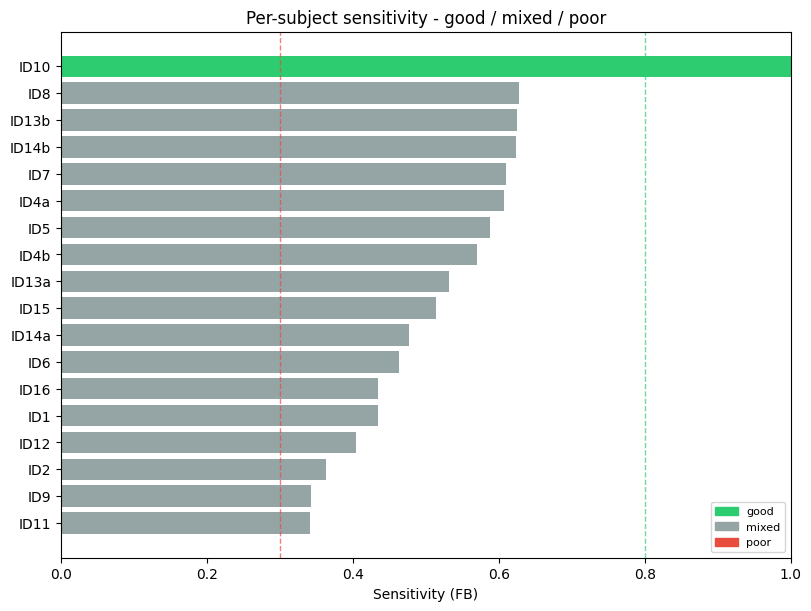

In [42]:
# -- Per-subject breakdown: good / mixed / poor patients --------------------
REPORT_SETTING = "FB"  # decoding strategy used for the per-subject report
GOOD_THRESHOLD = 0.80  # sensitivity >= this -> "good"
POOR_THRESHOLD = 0.30  # sensitivity <  this -> "poor"; everything else -> "mixed"

subject_meta = {
    fold["test_subject"]: {
        "n_files": len(np.unique(fold["file_stems"])),
        "n_windows": len(fold["y_true"]),
        "seizure_frac": float(fold["y_true"].mean()),
    }
    for fold in stored_folds
}

subj_df = (
    res_df[res_df["setting"] == REPORT_SETTING]
    .set_index("subject")[["sensitivity", "f2", "auroc"]]
    .join(pd.DataFrame(subject_meta).T)
    .sort_values("sensitivity")
)


def _flag(s):
    if s >= GOOD_THRESHOLD:
        return "good"
    if s < POOR_THRESHOLD:
        return "poor"
    return "mixed"


subj_df["flag"] = subj_df["sensitivity"].apply(_flag)

print(f"Per-subject breakdown  (setting = {REPORT_SETTING})")
print()
print(
    f"{'Subject':<8} {'Sens.':>7} {'F2':>7} {'AUROC':>7} "
    f"{'Files':>6} {'Windows':>8} {'Seiz.%':>7}  Flag"
)
print("-" * 68)
for subj, row in subj_df.iterrows():
    print(
        f"{subj:<8} {row['sensitivity']:>7.3f} {row['f2']:>7.3f} {row['auroc']:>7.3f} "
        f"{int(row['n_files']):>6d} {int(row['n_windows']):>8d} "
        f"{row['seizure_frac'] * 100:>6.1f}%  {row['flag']}"
    )

n_good = (subj_df["flag"] == "good").sum()
n_mixed = (subj_df["flag"] == "mixed").sum()
n_poor = (subj_df["flag"] == "poor").sum()
print()
print(
    f"{n_good} good  |  {n_mixed} mixed  |  {n_poor} poor   "
    f"(thresholds: good >= {GOOD_THRESHOLD}, poor < {POOR_THRESHOLD})"
)

if n_poor:
    print()
    print("Worst subjects (lowest sensitivity):")
    print(
        subj_df[subj_df["flag"] == "poor"][["sensitivity", "f2", "auroc"]].to_string(
            float_format=lambda v: f"{v:.3f}"
        )
    )
if n_good:
    print()
    print("Best subjects (highest sensitivity):")
    print(
        subj_df[subj_df["flag"] == "good"][["sensitivity", "f2", "auroc"]].to_string(
            float_format=lambda v: f"{v:.3f}"
        )
    )

# -- Bar chart ----------------------------------------------------------------
FLAG_COLORS = {"good": "#2ecc71", "mixed": "#95a5a6", "poor": "#e74c3c"}
fig, ax = plt.subplots(figsize=(8, 6), layout="constrained")
ax.barh(subj_df.index, subj_df["sensitivity"], color=subj_df["flag"].map(FLAG_COLORS))
ax.axvline(GOOD_THRESHOLD, color=FLAG_COLORS["good"], linestyle="--", linewidth=1, alpha=0.7)
ax.axvline(POOR_THRESHOLD, color=FLAG_COLORS["poor"], linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlim(0, 1)
ax.set_xlabel(f"Sensitivity ({REPORT_SETTING})")
ax.set_title("Per-subject sensitivity - good / mixed / poor")
ax.legend(
    handles=[Patch(color=v, label=k) for k, v in FLAG_COLORS.items()], loc="lower right", fontsize=8
)
plt.show()
plt.close(fig)

## 9c. Range of metrics across subjects

The table in Section 9 already reports `[min, max]` per setting; this boxplot shows the full
distribution — median, interquartile range, and individual per-subject points — so it is clear
whether the spread comes from a couple of outlier patients or is spread evenly across all 18.

C:\Users\rescic\AppData\Local\Temp\ipykernel_246716\383220408.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Raw", "Viterbi", "FB"], showmeans=True)
C:\Users\rescic\AppData\Local\Temp\ipykernel_246716\383220408.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Raw", "Viterbi", "FB"], showmeans=True)
C:\Users\rescic\AppData\Local\Temp\ipykernel_246716\383220408.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Raw", "Viterbi", "FB"], showmeans=True)


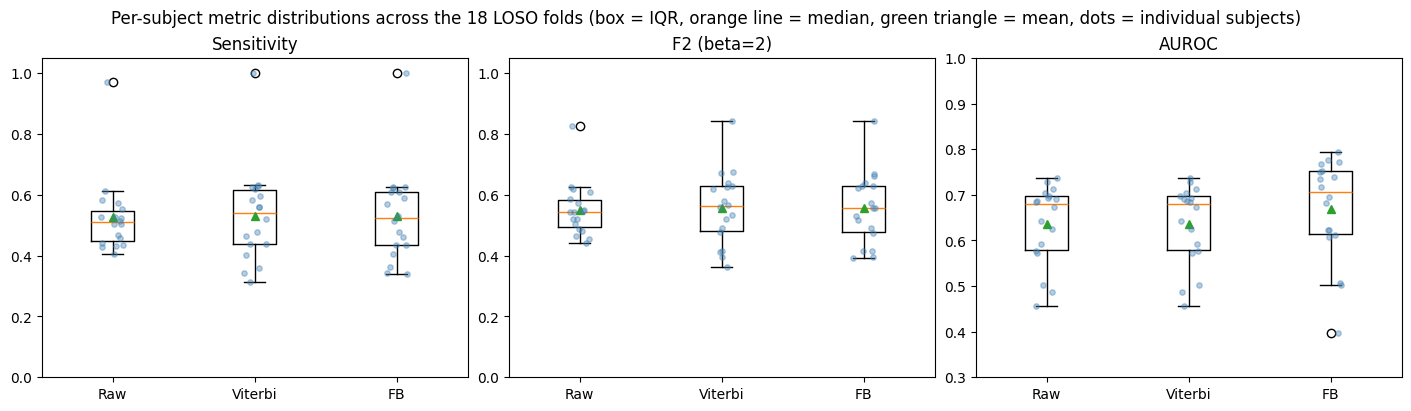

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
rng = np.random.default_rng(0)
for ax, metric, nice, ylim in zip(
    axes,
    ["sensitivity", "f2", "auroc"],
    ["Sensitivity", "F2 (beta=2)", "AUROC"],
    [(0, 1.05), (0, 1.05), (0.3, 1.0)],
    strict=True,
):
    data = [
        res_df.loc[res_df["setting"] == s, metric].dropna().to_numpy()
        for s in ["Raw", "Viterbi", "FB"]
    ]
    ax.boxplot(data, labels=["Raw", "Viterbi", "FB"], showmeans=True)
    for i, d in enumerate(data, start=1):
        ax.scatter(
            i + rng.uniform(-0.08, 0.08, len(d)), d, alpha=0.4, s=15, color="steelblue", zorder=3
        )
    ax.set_title(nice)
    ax.set_ylim(*ylim)
fig.suptitle(
    "Per-subject metric distributions across the 18 LOSO folds "
    "(box = IQR, orange line = median, green triangle = mean, dots = individual subjects)"
)
plt.show()
plt.close(fig)

## 10. Time-series visualisation

Five rows per recording:

1. **Ground truth** — the labelled seizure segment
2. **P(seizure)** — raw classifier output; should show a clear step at onset/offset
3. **Raw** — hard labels from argmax of classifier probs
4. **Viterbi** — HMM smoothed hard labels; short spurious spikes removed
5. **FB posterior** — forward-backward P(seizure); smooth probability incorporating all temporal context

**Why cap the number of figures?** `N_SUBJECTS_PLOT` limits how many *subjects* are shown, but
some subjects have many recordings each (e.g. `ID1` has 13 seizure files, `ID4b` has 7) — plotting
every recording for those subjects alone can generate dozens of large figures and exhaust kernel
memory. `MAX_PLOTS` is a hard ceiling on the total figure count, and each figure is closed with
`plt.close(fig)` right after display so memory doesn't accumulate across the loop.

**Common failure patterns to watch for:**

- **False positives right at the non-seizure margins** — the 3-min boundary is sharp in the
  labels but brain activity transitions gradually; predictions near the margin may reflect real
  peri-ictal activity rather than model error.
- **Fragmented Raw predictions** — if row 3 (Raw) oscillates rapidly, rows 4/5 (Viterbi/FB) should
  visibly stabilise it. If they don't, the transition matrix's self-transition probabilities may
  be too low for this recording's seizure duration.

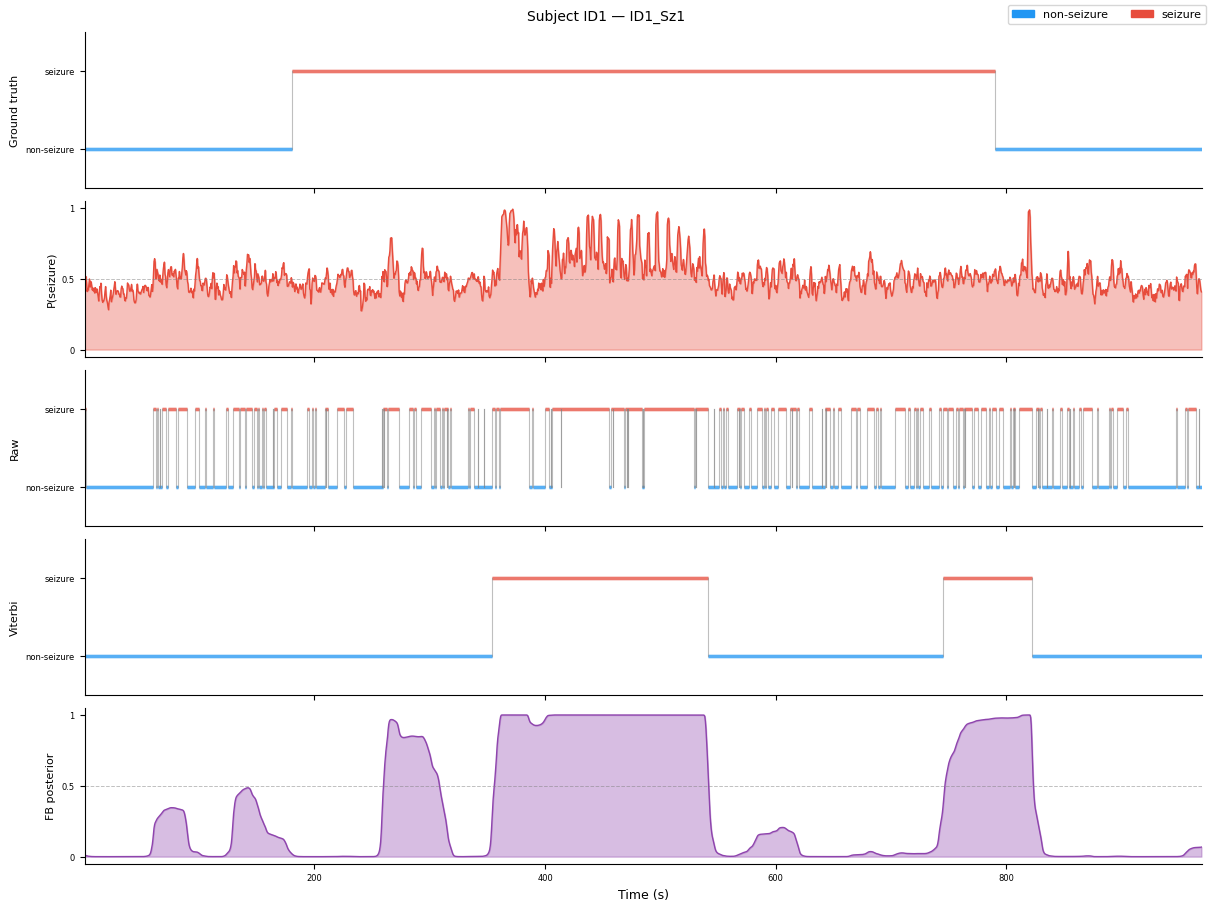

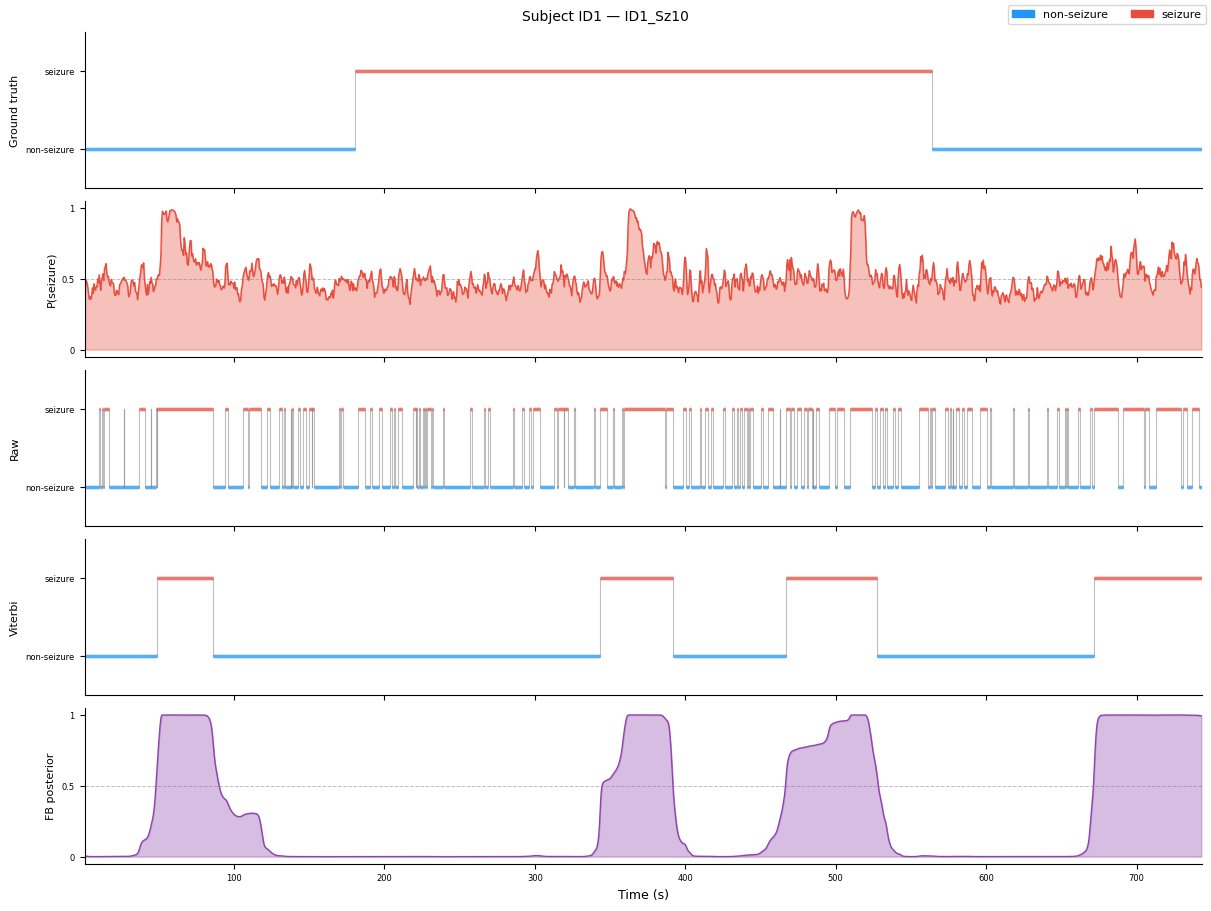

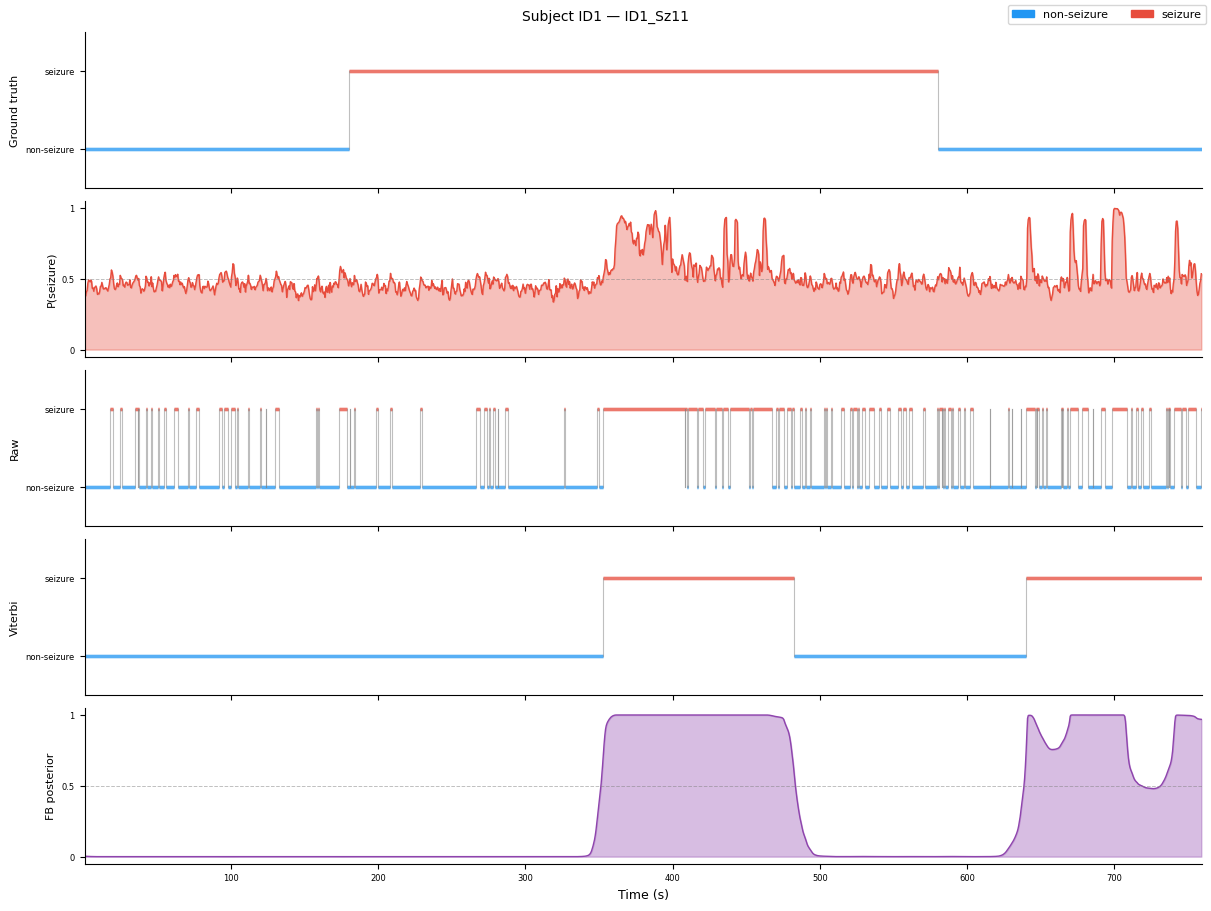

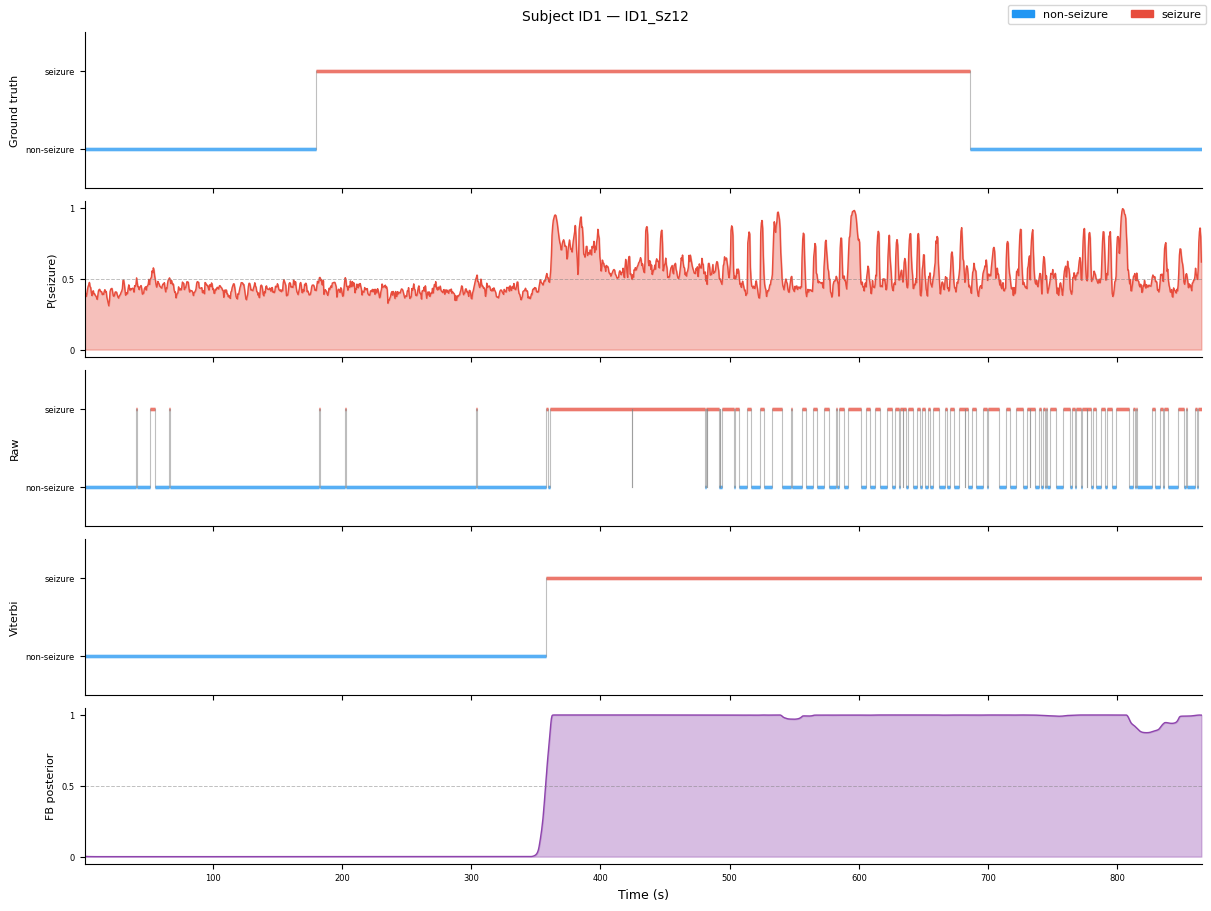

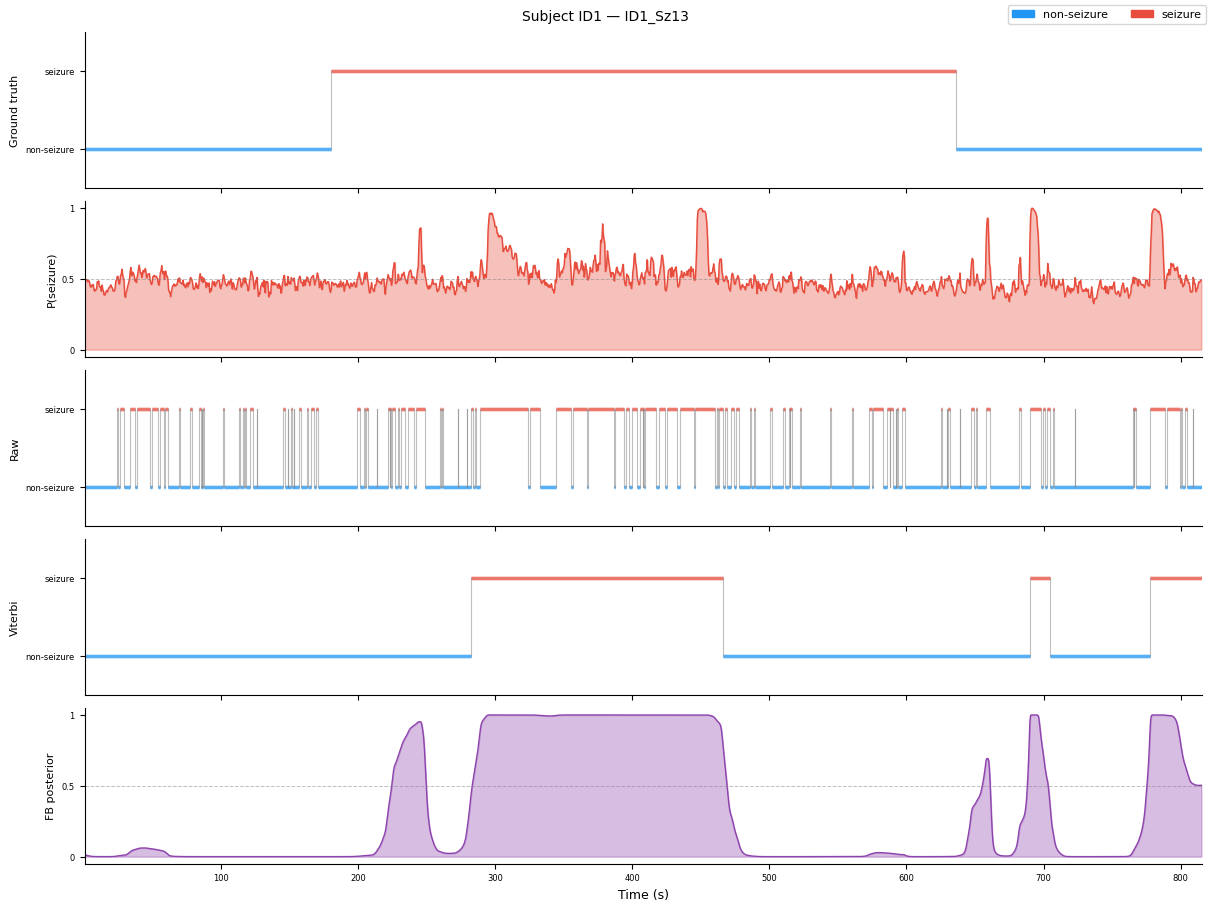

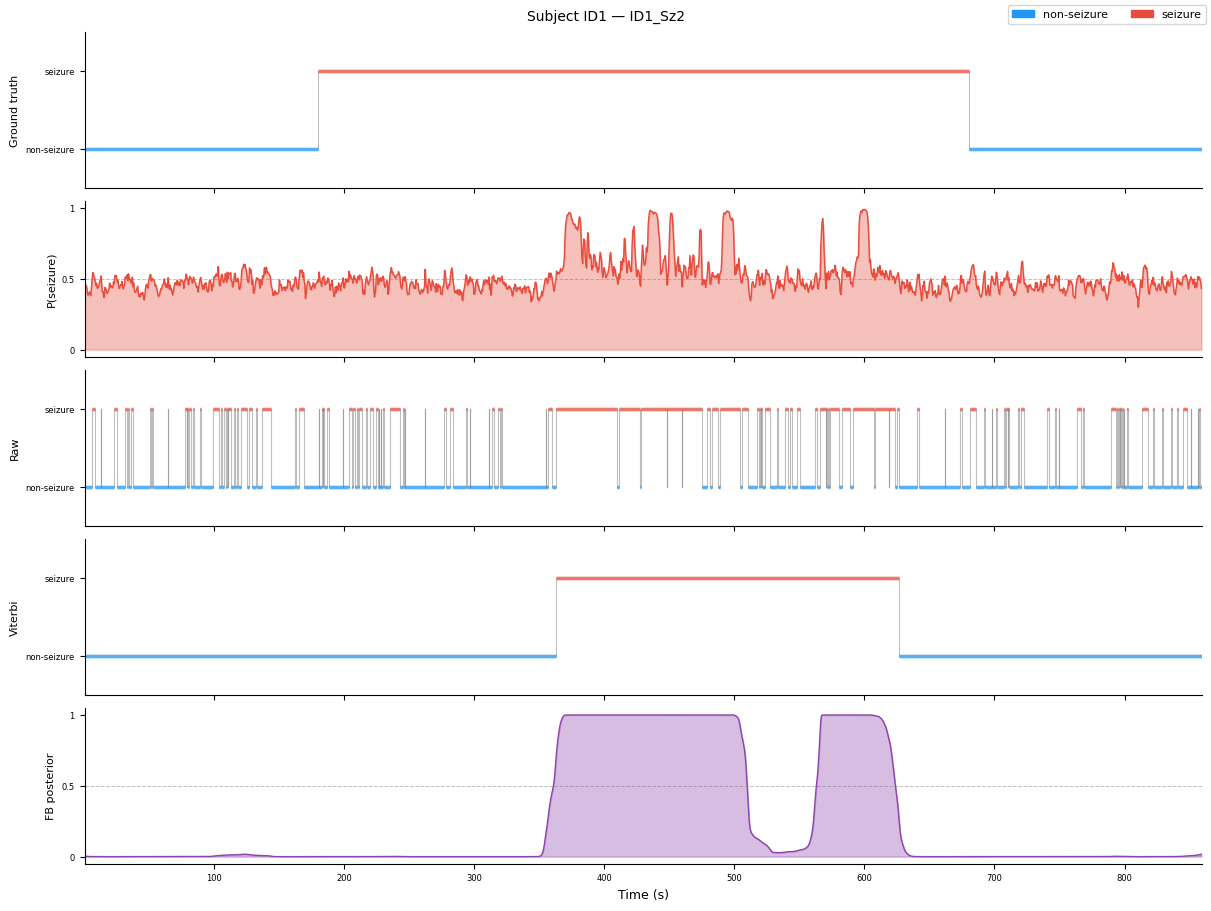

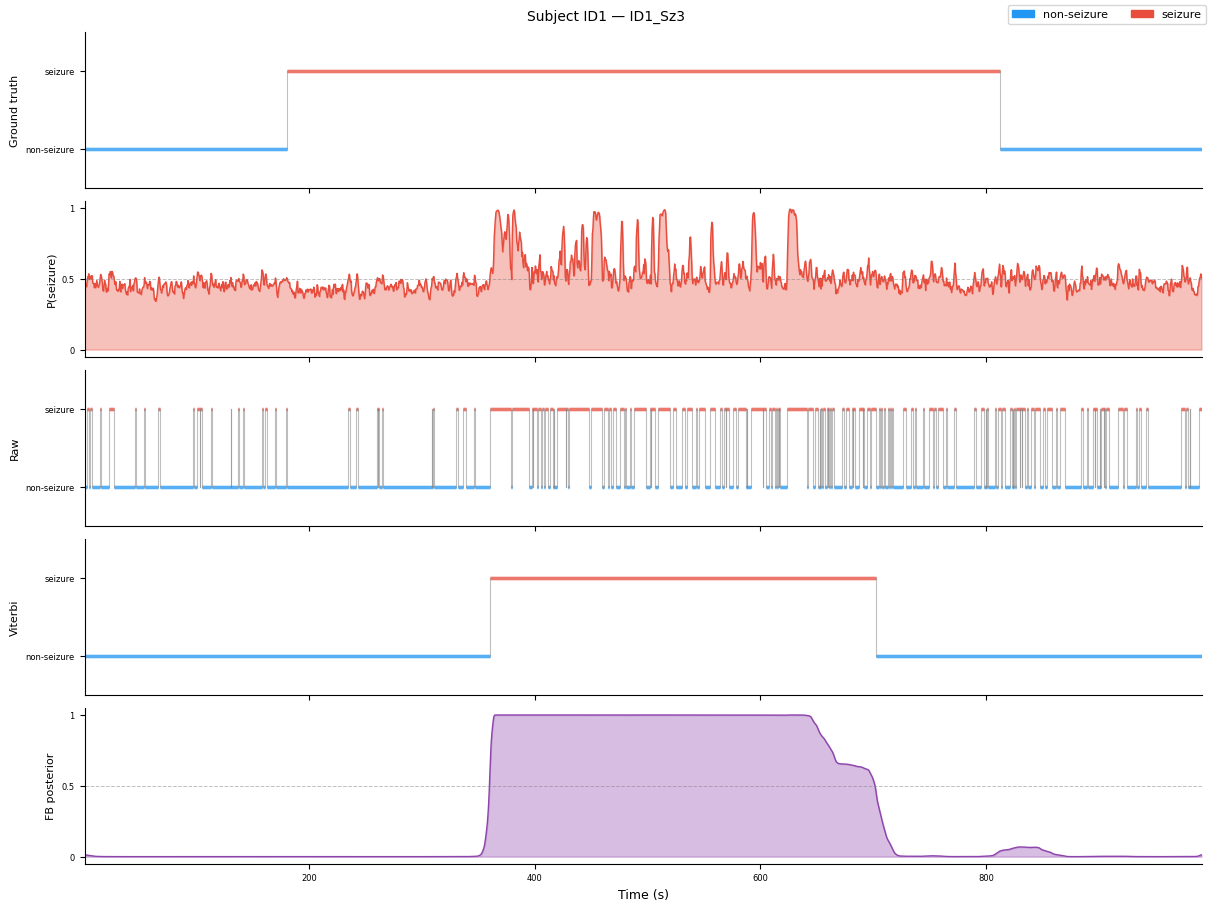

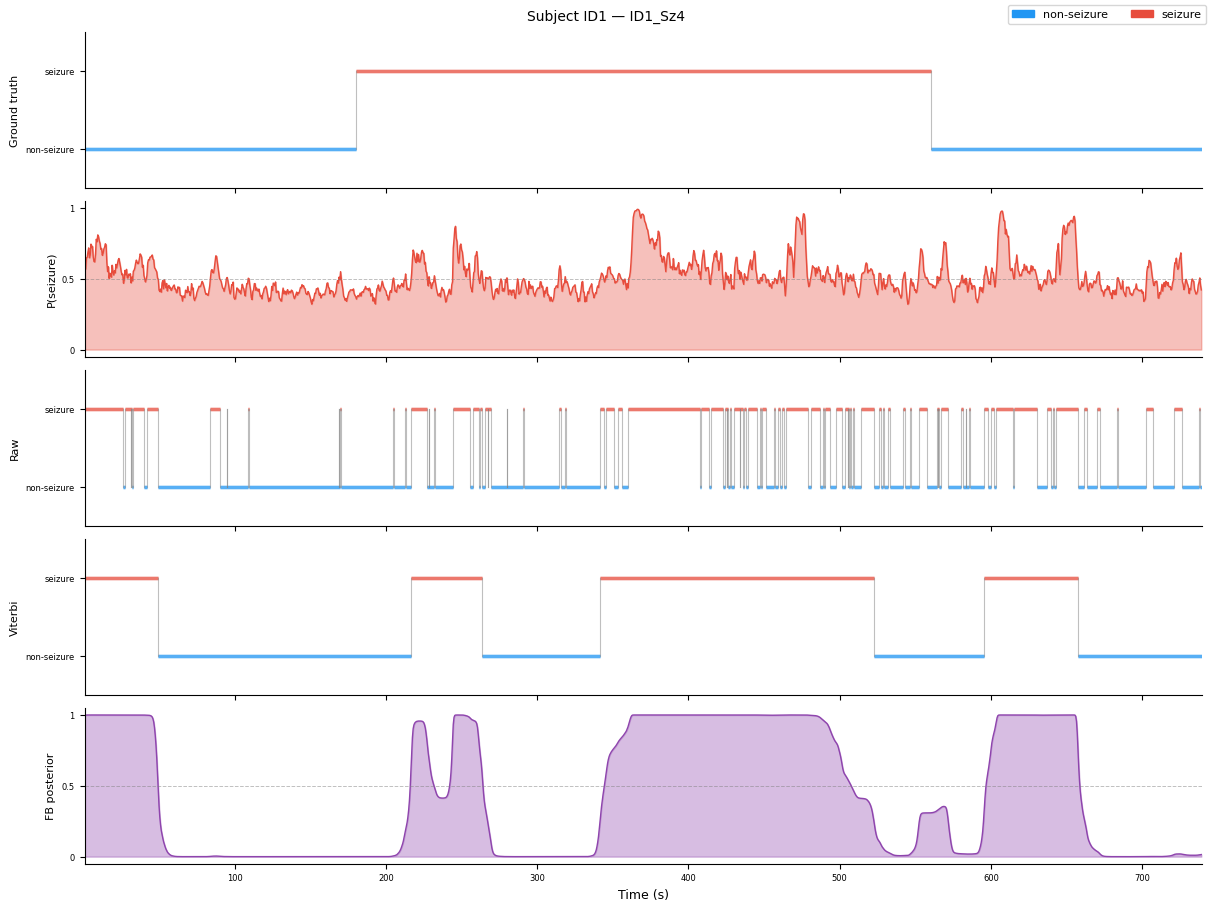

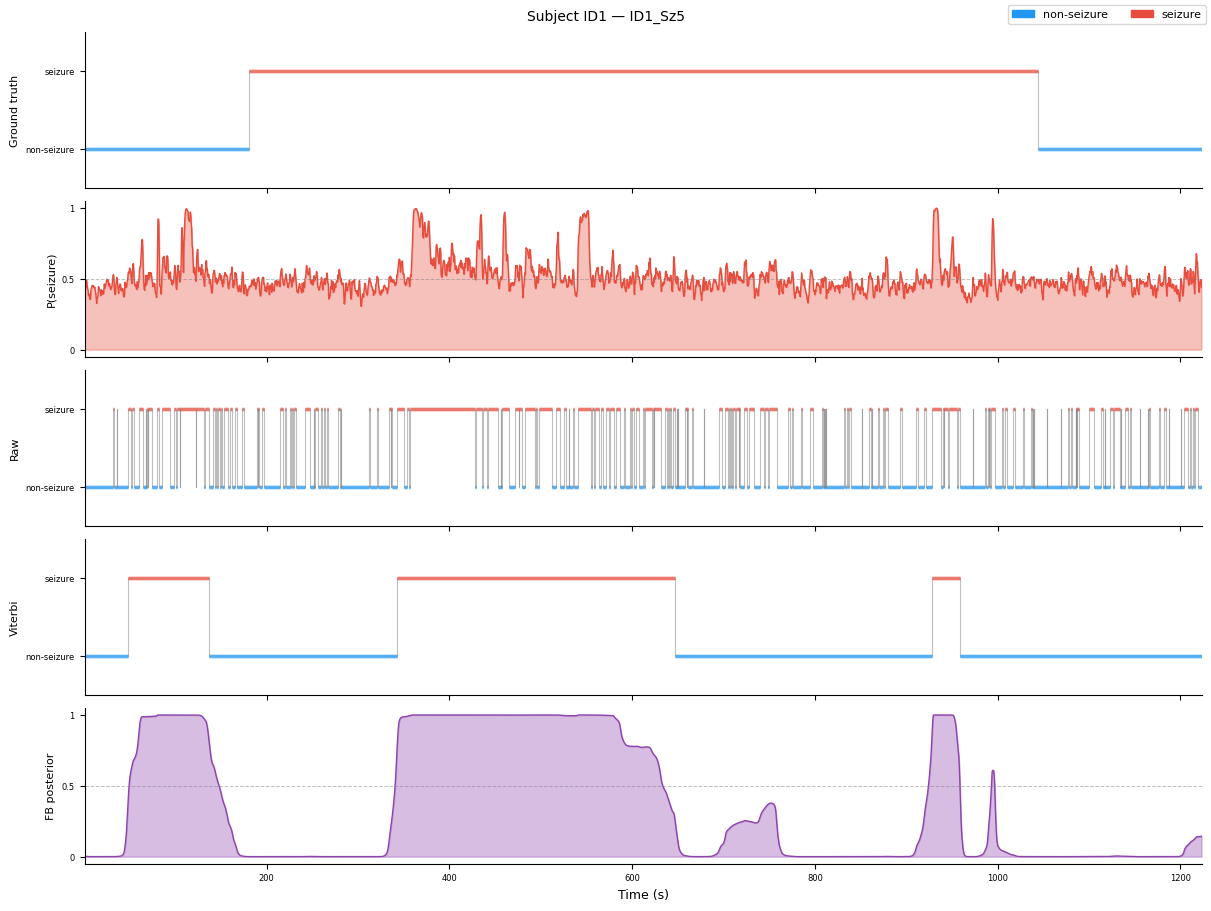

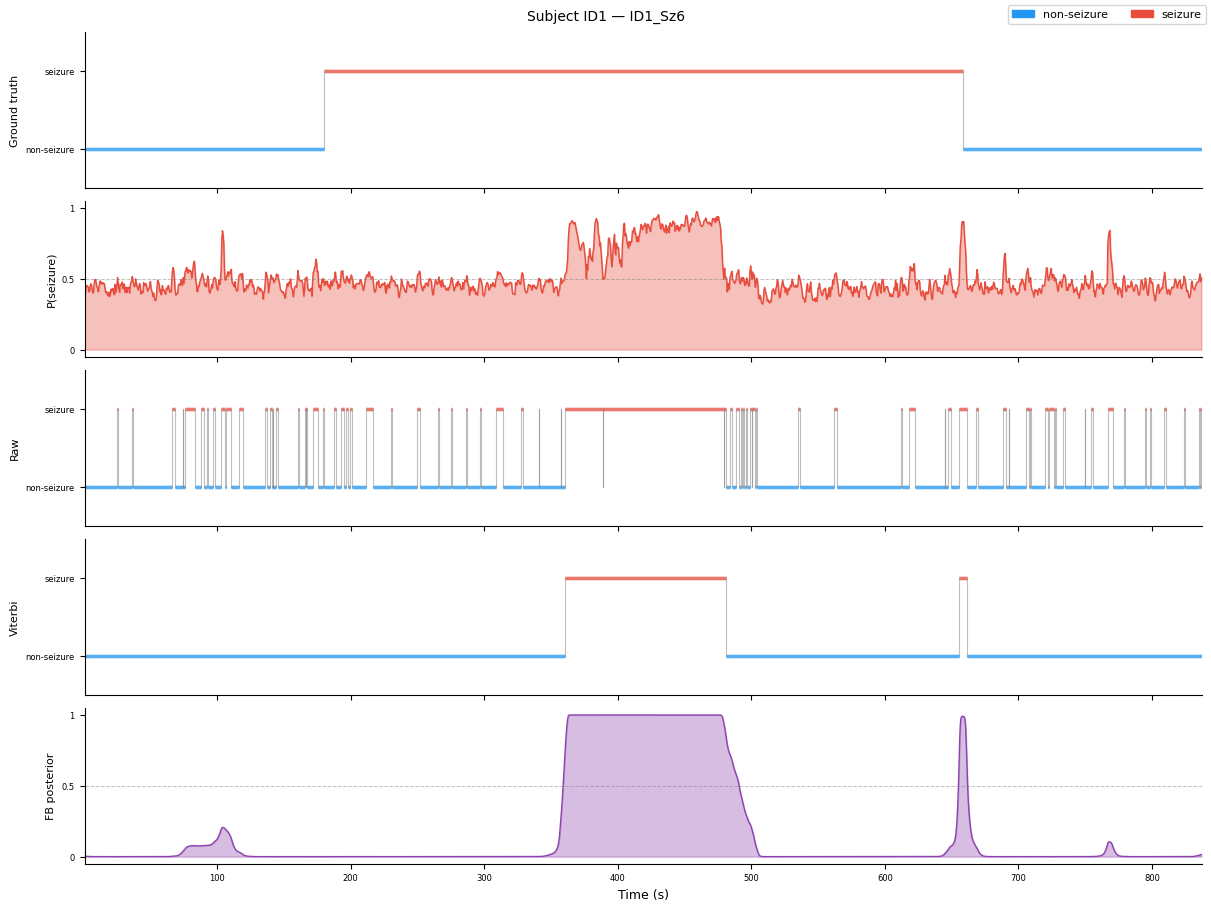

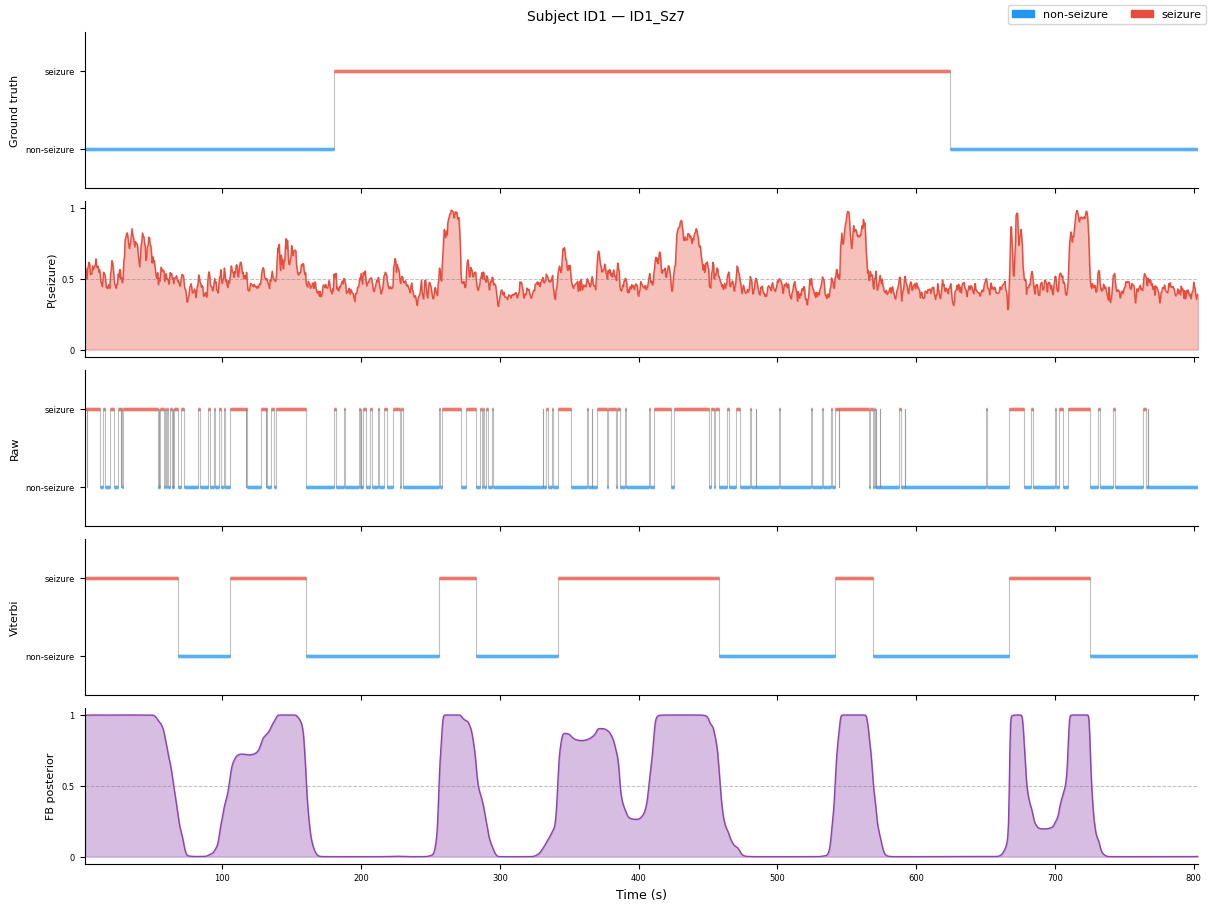

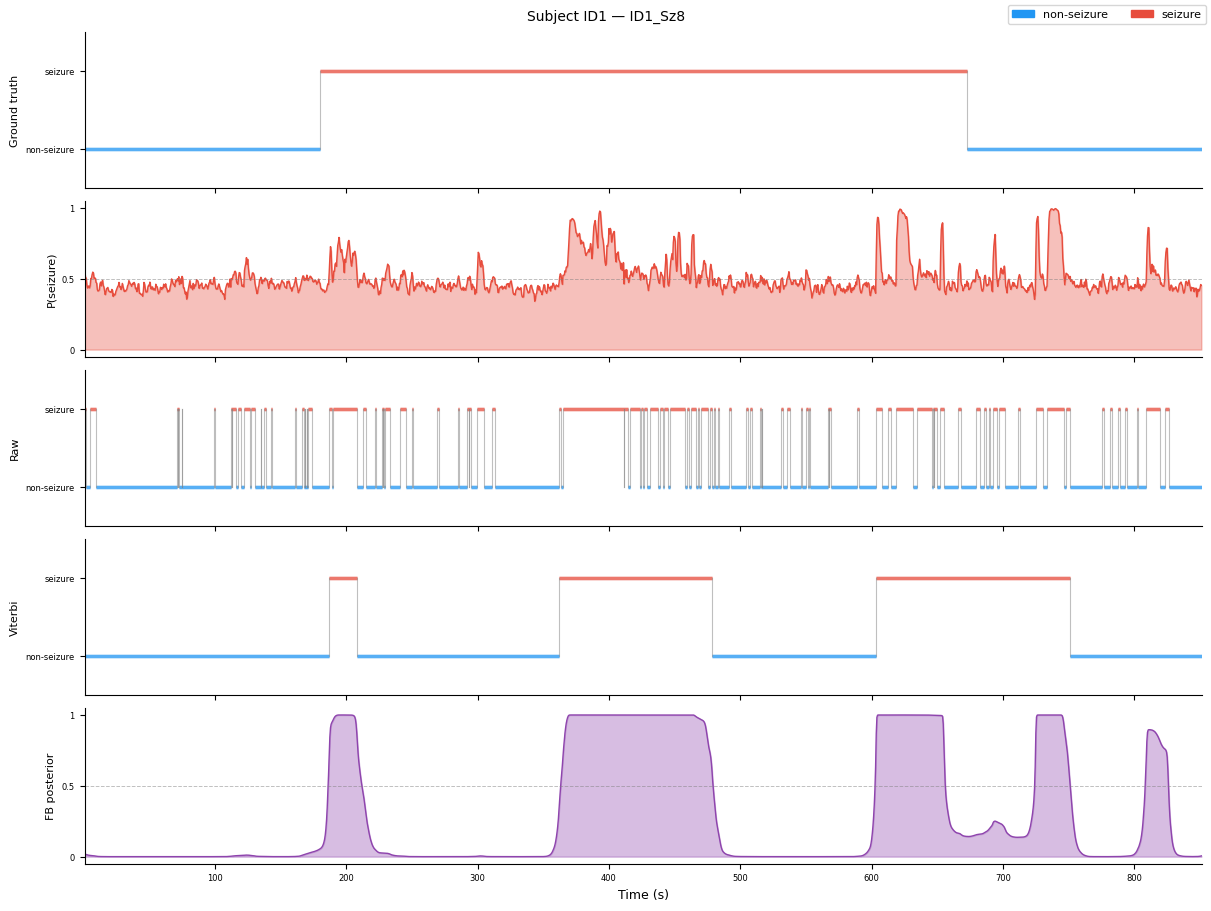

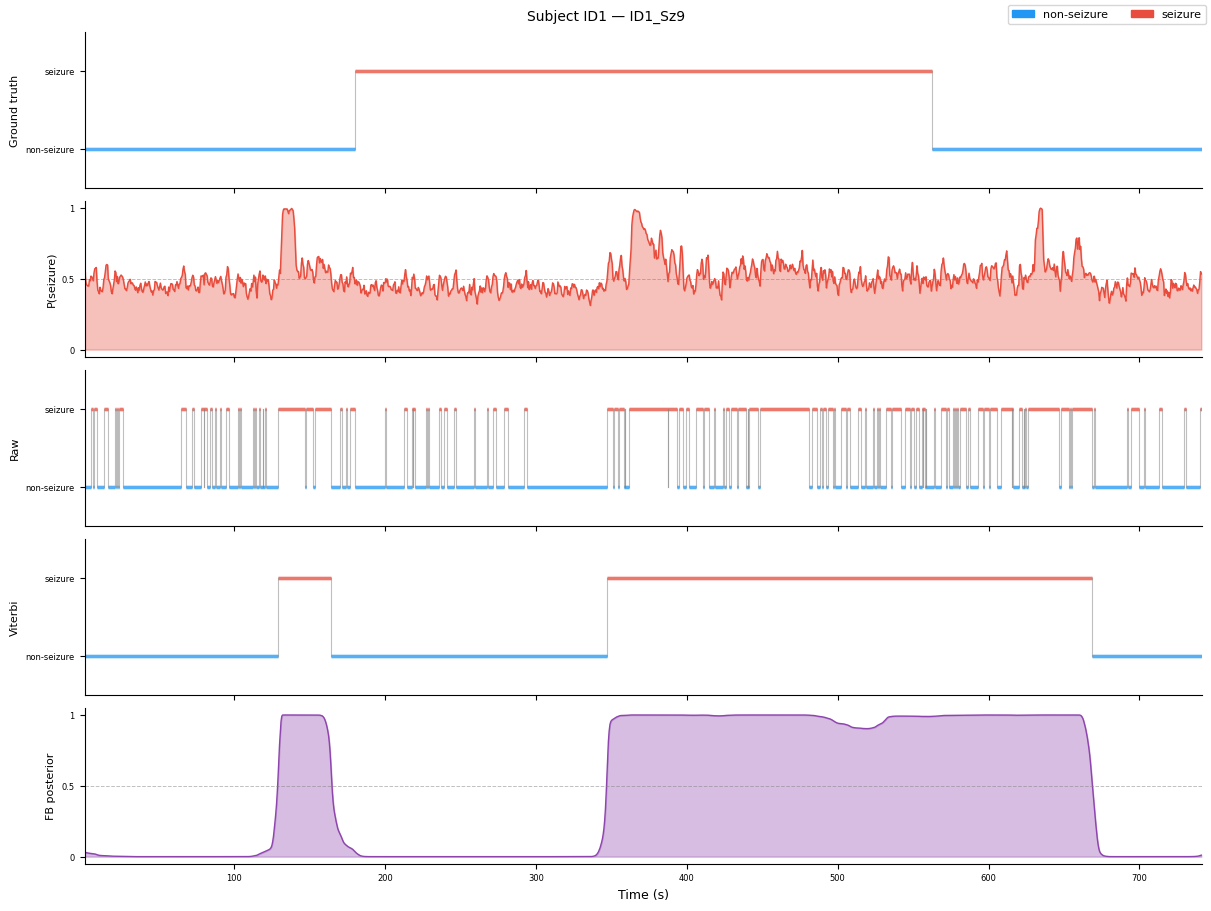

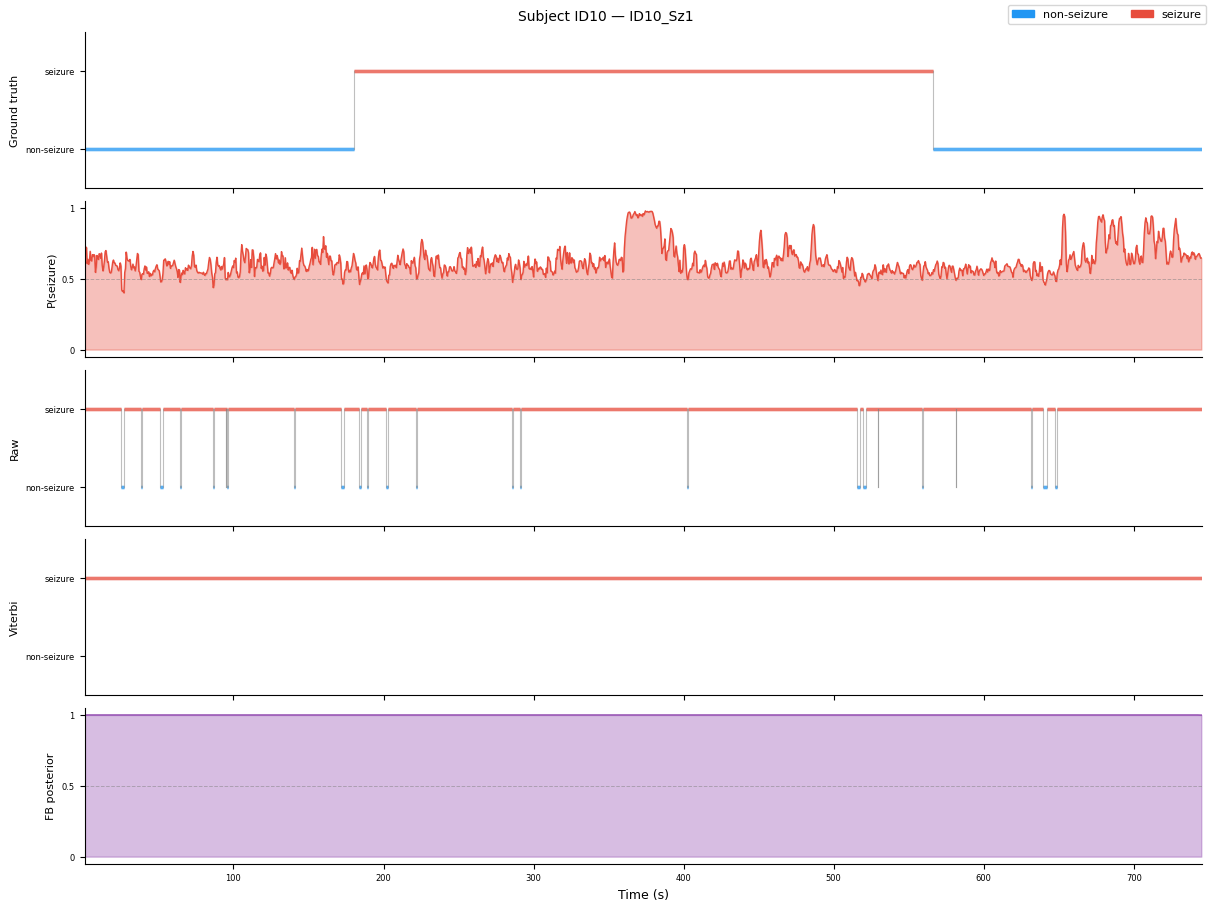

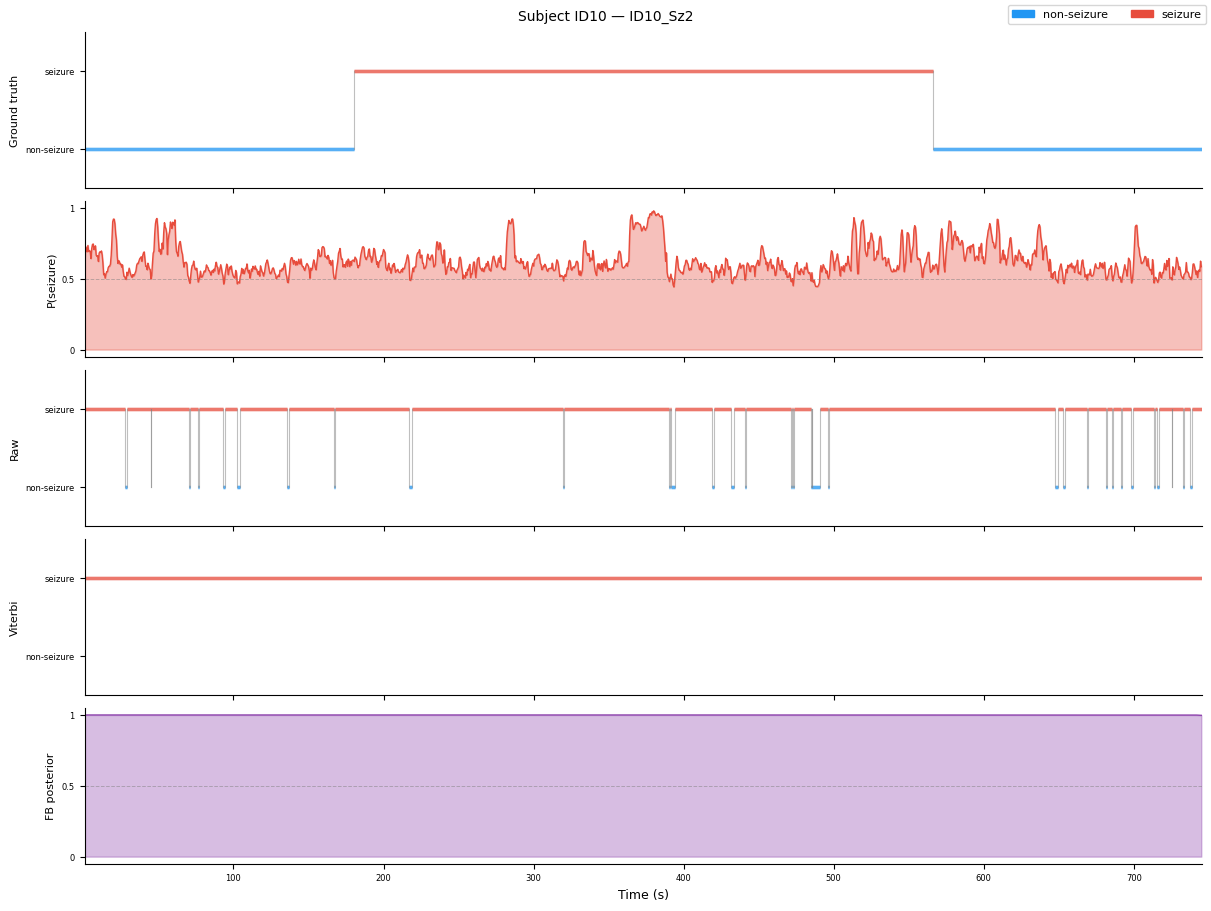

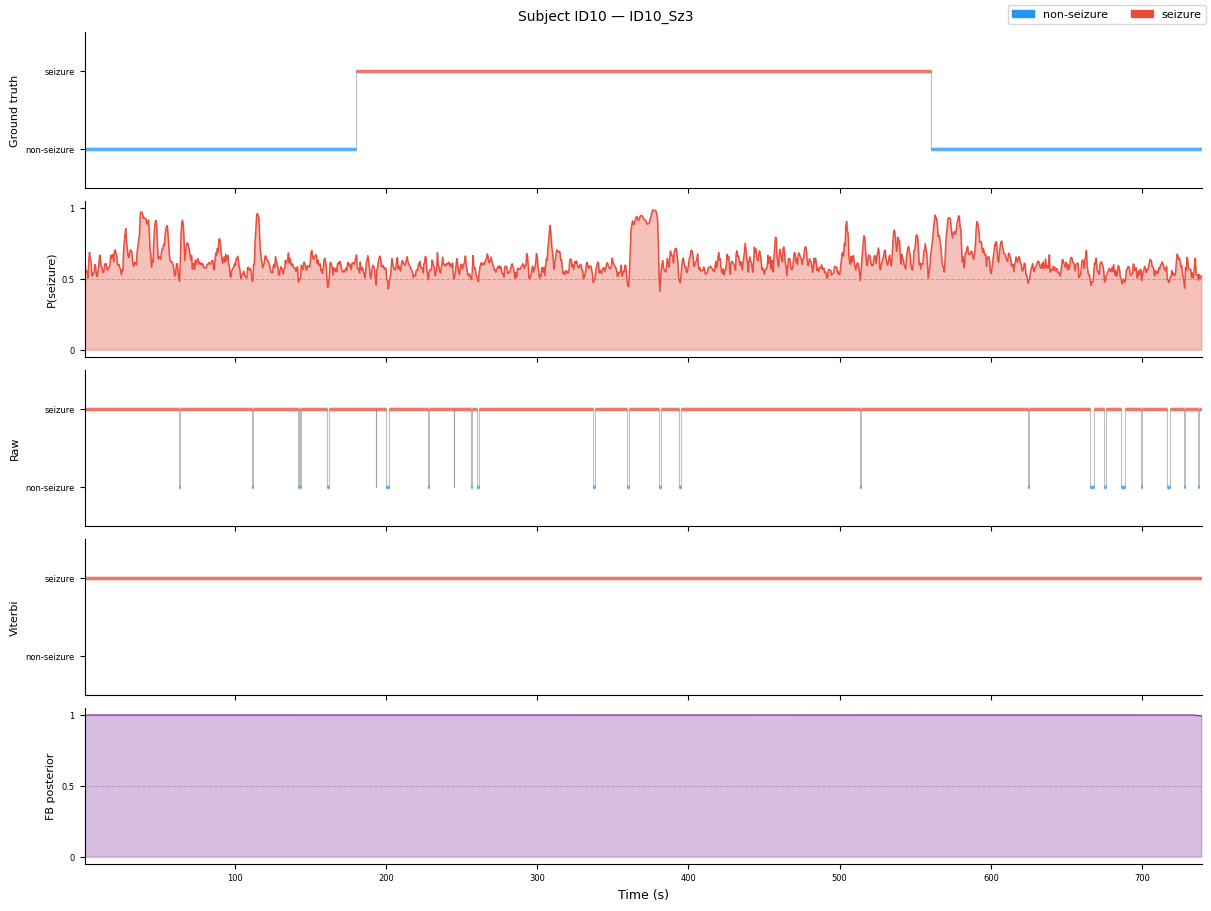

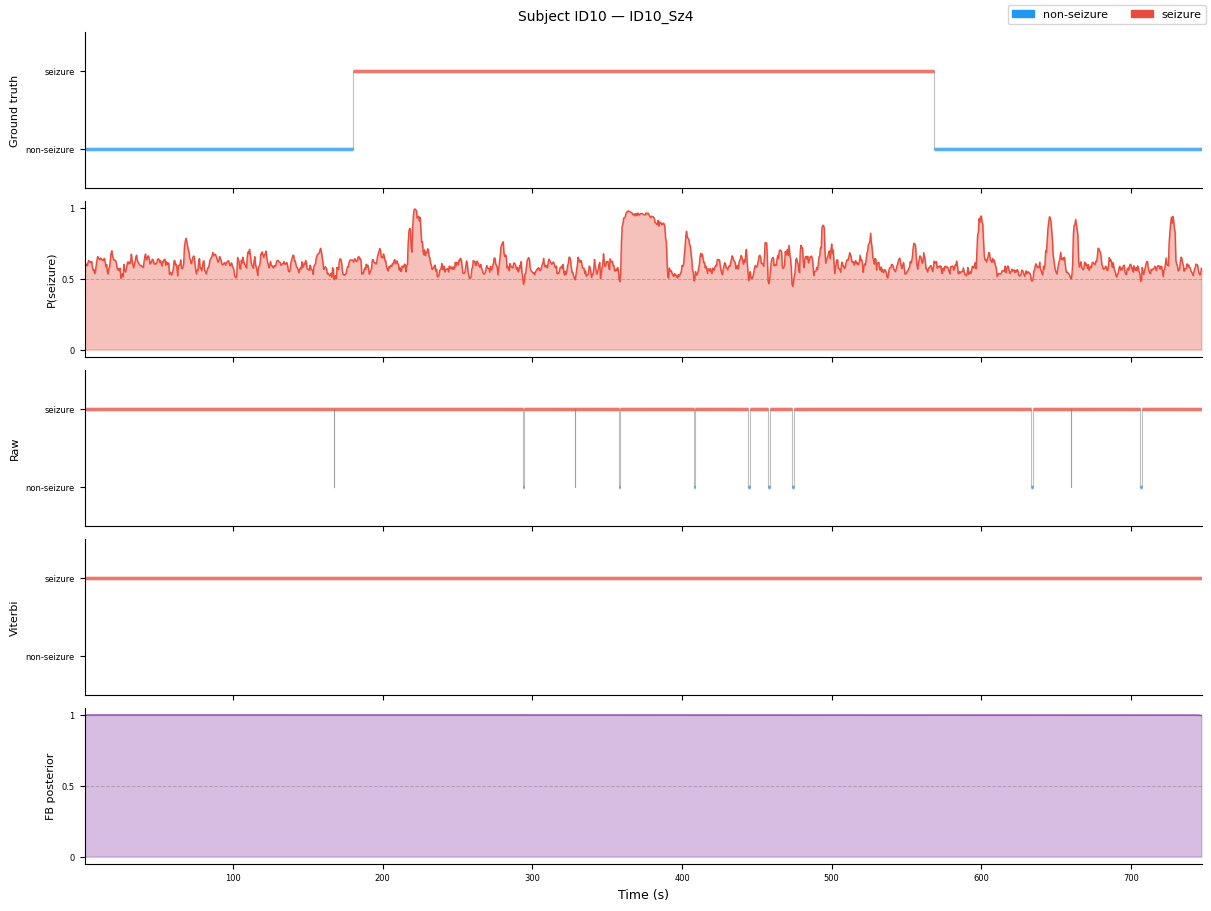

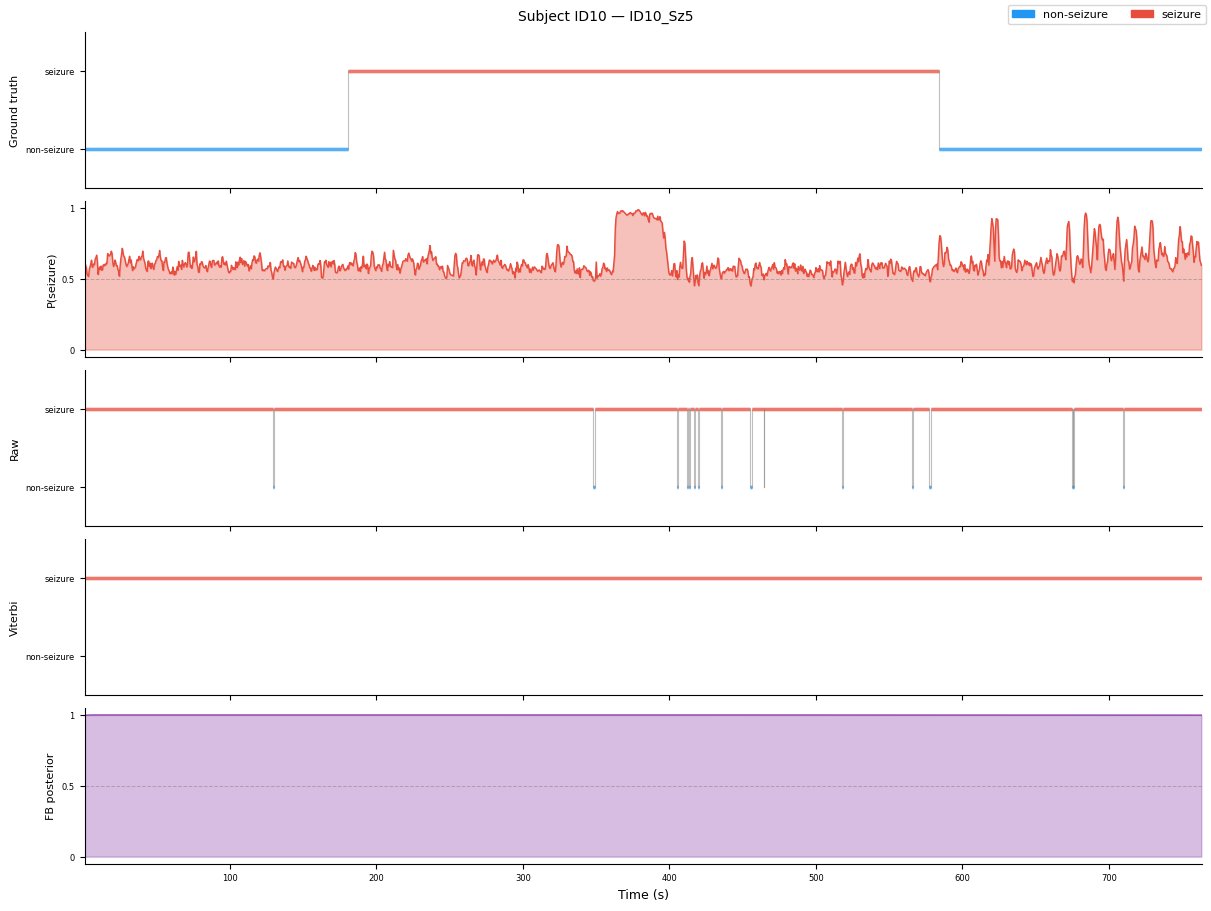

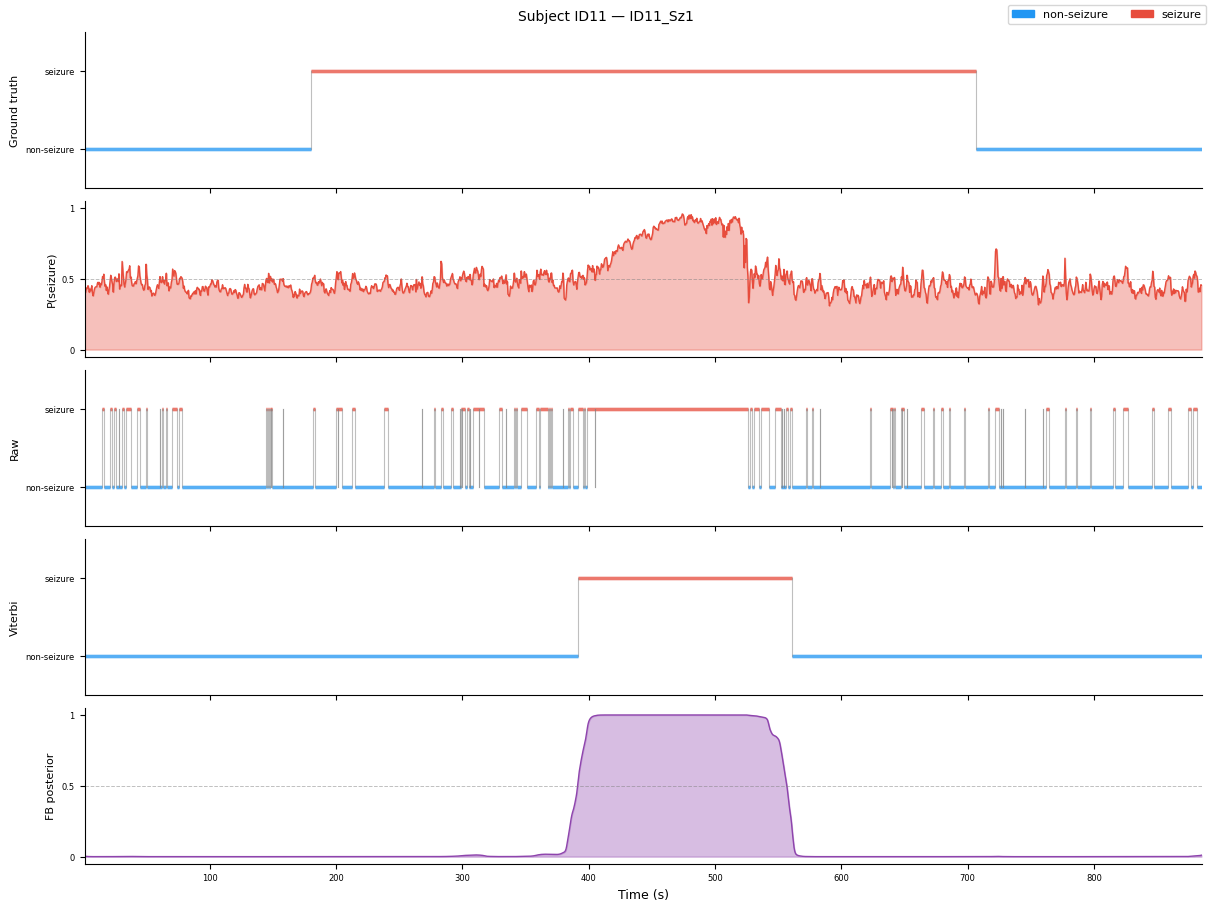

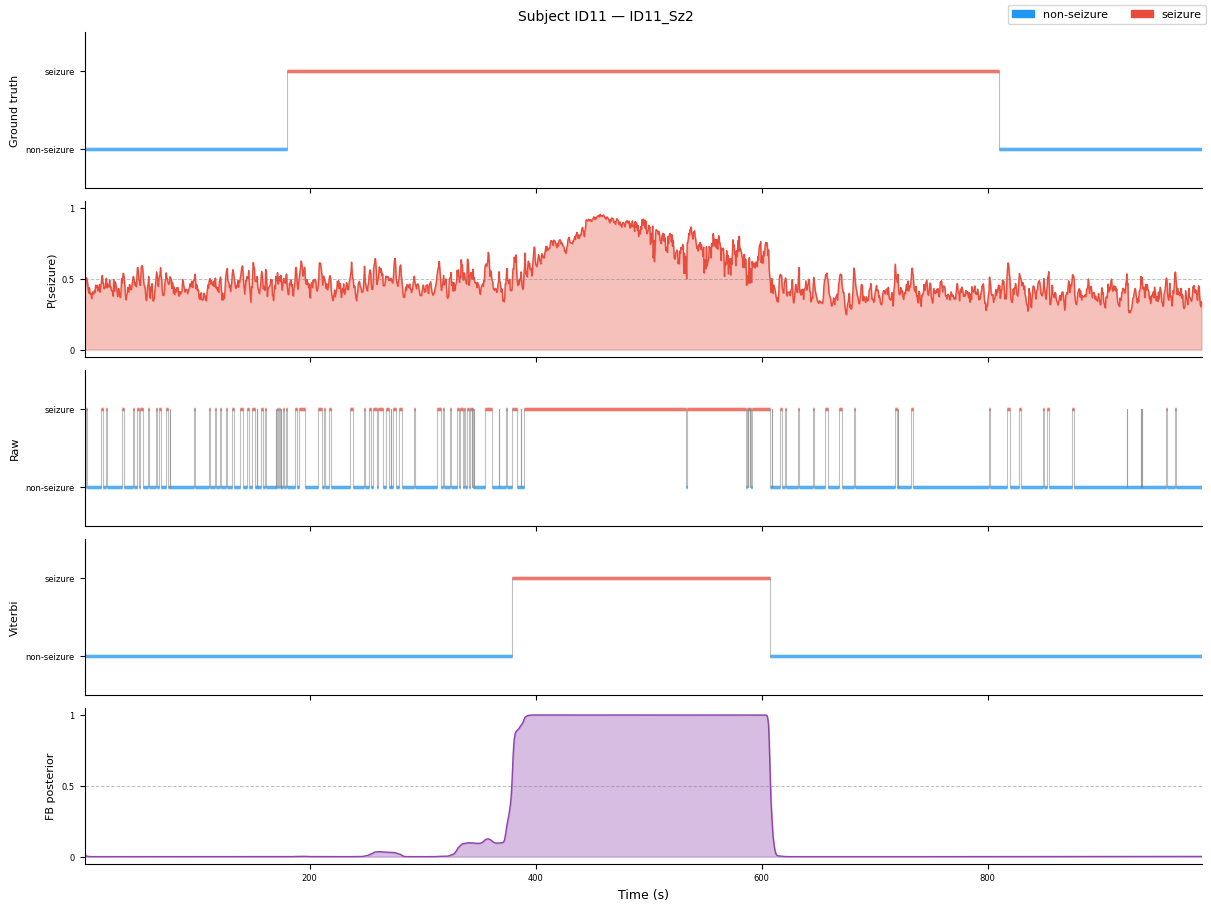

(stopped after 20 figures — raise MAX_PLOTS to see more)


In [44]:
N_SUBJECTS_PLOT = 4  # set None to show all subjects
MAX_PLOTS = 20  # hard cap on total figures rendered — protects the kernel from
# subjects with many recordings (e.g. ID1 has 13 seizure files)

CLASS_COLORS = {0: "#2196F3", 1: "#e74c3c"}
CLASS_NAMES = {0: "non-seizure", 1: "seizure"}
FB_COLOR = "#8e44ad"
ROW_LABELS = ["Ground truth", "P(seizure)", "Raw", "Viterbi", "FB posterior"]


def _draw_hard(ax, times, labels, color_map, class_names):
    labels = np.asarray(labels, dtype=int)
    if len(times) > 1:
        dt = np.median(np.diff(times))
        t_l = np.concatenate([[times[0] - dt / 2], (times[:-1] + times[1:]) / 2])
        t_r = np.concatenate([(times[:-1] + times[1:]) / 2, [times[-1] + dt / 2]])
    else:
        dt = 5.0
        t_l = [times[0] - dt / 2]
        t_r = [times[0] + dt / 2]
    segs = [[(t_l[i], labels[i]), (t_r[i], labels[i])] for i in range(len(times))]
    ax.add_collection(
        LineCollection(
            segs, colors=[color_map[lbl] for lbl in labels], linewidths=2.5, capstyle="butt"
        )
    )
    for i in range(len(times) - 1):
        if labels[i] != labels[i + 1]:
            ax.plot(
                [t_r[i], t_r[i]], [labels[i], labels[i + 1]], color="gray", linewidth=0.8, alpha=0.5
            )
    ax.set_xlim(times[0] - dt / 2, times[-1] + dt / 2)
    ax.set_ylim(-0.5, len(class_names) - 0.5)
    ax.set_yticks(list(class_names))
    ax.set_yticklabels(list(class_names.values()), fontsize=6)
    ax.tick_params(left=True, labelsize=6)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)


def _draw_prob(ax, times, p, color):
    ax.fill_between(times, 0, p, alpha=0.35, color=color)
    ax.plot(times, p, color=color, linewidth=1.0)
    ax.axhline(0.5, color="gray", linewidth=0.7, linestyle="--", alpha=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"], fontsize=6)
    ax.tick_params(left=True, labelsize=6)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)


legend_patches = [Patch(color=v, label=CLASS_NAMES[k]) for k, v in CLASS_COLORS.items()]

subjects_shown = 0
plots_shown = 0
for fold in stored_folds:
    if N_SUBJECTS_PLOT and subjects_shown >= N_SUBJECTS_PLOT:
        break
    if MAX_PLOTS and plots_shown >= MAX_PLOTS:
        break
    for stem in np.unique(fold["file_stems"]):
        if MAX_PLOTS and plots_shown >= MAX_PLOTS:
            break
        mask = fold["file_stems"] == stem
        order = np.argsort(fold["window_mid_s"][mask])
        times = fold["window_mid_s"][mask][order]
        gt = fold["y_true"][mask][order]
        probs_here = fold["probs"][mask][order]
        stems_here = fold["file_stems"][mask][order]

        hmm_pred = viterbi_smooth(fold["y_train"], stems_here, probs_here)
        fb_post = fb_smooth(fold["y_train"], stems_here, probs_here)

        fig, axes = plt.subplots(5, 1, figsize=(12, 9), sharex=True, layout="constrained")

        _draw_hard(axes[0], times, gt, CLASS_COLORS, CLASS_NAMES)
        _draw_prob(axes[1], times, probs_here[:, 1], CLASS_COLORS[1])
        _draw_hard(axes[2], times, probs_here.argmax(axis=1), CLASS_COLORS, CLASS_NAMES)
        _draw_hard(axes[3], times, hmm_pred, CLASS_COLORS, CLASS_NAMES)
        _draw_prob(axes[4], times, fb_post[:, 1], FB_COLOR)
        axes[4].set_xlabel("Time (s)", fontsize=9)

        for i, label in enumerate(ROW_LABELS):
            axes[i].set_ylabel(label, fontsize=8, labelpad=4)

        fig.legend(handles=legend_patches, loc="upper right", fontsize=8, framealpha=0.8, ncol=2)
        fig.suptitle(f"Subject {fold['test_subject']} — {stem}", fontsize=10)
        plt.show()
        plt.close(fig)
        plots_shown += 1
    subjects_shown += 1

if plots_shown == MAX_PLOTS:
    print(f"(stopped after {MAX_PLOTS} figures — raise MAX_PLOTS to see more)")

## 11. Summary and next steps

This notebook ran a single, well-understood detection pipeline (LogisticRegression, binary labels,
`class_weight="balanced"` imbalance handling) end to end on the SWEZ short dataset with
Leave-One-Subject-Out validation and HMM post-processing. It originally used XGBoost; that was
replaced with LogisticRegression after the full pipeline notebook showed both achieve essentially
identical AUROC under LOSO, making the simpler, faster, interpretable model the better default
(see Section 6).

### Known simplifications vs. the full pipeline

- **Split-session subjects are not merged** (`ID13a`/`ID13b`, `ID14a`/`ID14b`, `ID4a`/`ID4b`) —
  see the note in Section 2. This mildly leaks information across roughly 6 of 18 LOSO folds.
- **Single classifier, binary labels only** — no cross-model comparison and no 4-class
  pre-/post-seizure transition modelling.

### Potential next steps

| Direction | What to try |
|-----------|-------------|
| **Fix subject merging** | Port `canonical_subject_id()` from the full pipeline to get a clean 15-subject LOSO |
| **Add specificity/precision** | Section 9's table only reports sensitivity/F2/AUROC — add specificity and precision so a degenerate "always predict seizure" model can't hide |
| **Re-check non-linear models** | Re-introduce RandomForest/XGBoost as in the full pipeline to confirm LogisticRegression's simplicity isn't leaving real performance on the table once features change |
| **4-class labels** | Add pre-/post-seizure transition zones to reduce hard false positives at onset/offset |
| **Onset latency analysis** | Measure how many windows after true onset the model first correctly detects the seizure |